# AML Detection: Merged IBM + SAML-D

This notebook merges the IBM AML transaction data with SAML-D style synthetic transactions, engineers leak-aware historical features, benchmarks several AML modeling techniques, and explains the result with correlations, lift, rankings, and alert examples.

PR-AUC note: with laundering prevalence this small, a raw PR-AUC can look numerically low even when the model is materially better than random. That is why this notebook reports both `pr_auc` and `pr_lift` relative to the baseline positive rate.


In [71]:
%pip install -q pandas numpy scikit-learn xgboost imbalanced-learn pyarrow seaborn matplotlib joblib


In [72]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")


## Paths

Update these paths if your files live somewhere else in the connected Colab runtime. The notebook now tries to auto-discover matching CSV files under common Colab, Kaggle, Drive, and current-working-directory locations if the exact path is missing.

In [73]:
IBM_PATH = Path('/content/aml_merged/raw/ibm/HI-Small_Trans.csv')
SAML_PATH = Path('/content/aml_merged/raw/saml')

SEARCH_ROOTS = [
    Path('/content'),
    Path('/kaggle/input'),
    Path('/content/drive/MyDrive'),
    Path.cwd(),
]

FAST_MODE = False
FORCE_REBUILD_FEATURES = False
MODEL_SEARCH_MODE = 'quick' if FAST_MODE else 'full'

MAX_IBM_ROWS = 300_000 if FAST_MODE else None
MAX_SAML_ROWS = 300_000 if FAST_MODE else None
RANDOM_STATE = 42

ARTIFACT_DIR = Path('/content/aml_merged/artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = ARTIFACT_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE_PATH = CACHE_DIR / f"engineered_features_ibm_{MAX_IBM_ROWS or 'all'}_saml_{MAX_SAML_ROWS or 'all'}.parquet"

print('IBM_PATH =', IBM_PATH)
print('SAML_PATH =', SAML_PATH)
print('SEARCH_ROOTS =', SEARCH_ROOTS)
print('FAST_MODE =', FAST_MODE)
print('MODEL_SEARCH_MODE =', MODEL_SEARCH_MODE)
print('FORCE_REBUILD_FEATURES =', FORCE_REBUILD_FEATURES)
print('FEATURE_CACHE_PATH =', FEATURE_CACHE_PATH)
print('ARTIFACT_DIR =', ARTIFACT_DIR)

IBM_PATH = /content/aml_merged/raw/ibm/HI-Small_Trans.csv
SAML_PATH = /content/aml_merged/raw/saml
SEARCH_ROOTS = [PosixPath('/content'), PosixPath('/kaggle/input'), PosixPath('/content/drive/MyDrive'), PosixPath('/content')]
FAST_MODE = False
MODEL_SEARCH_MODE = full
FORCE_REBUILD_FEATURES = False
FEATURE_CACHE_PATH = /content/aml_merged/artifacts/cache/engineered_features_ibm_all_saml_all.parquet
ARTIFACT_DIR = /content/aml_merged/artifacts


## Core Pipeline Utilities
*All utility functions are defined in the cells below, grouped by responsibility. Run all groups before executing the pipeline cells.*


In [ ]:
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier


UNIFIED_COLUMNS = [
    "source_dataset",
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "transaction_amount",
    "amount_paid",
    "amount_received",
    "payment_currency",
    "receiving_currency",
    "payment_format",
    "transaction_type",
    "laundering_type",
    "is_laundering",
]


### Metrics & Device Utilities


In [ ]:
def safe_roc_auc(y_true, scores):
    y_array = np.asarray(y_true).astype(int)
    if len(np.unique(y_array)) < 2:
        return 0.0
    return float(roc_auc_score(y_array, scores))


def safe_pr_auc(y_true, scores):
    y_array = np.asarray(y_true).astype(int)
    if len(np.unique(y_array)) < 2:
        return 0.0
    return float(average_precision_score(y_array, scores))


def get_xgb_device():
    try:
        import torch

        return "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        return "cpu"


COMMON_DATASET_SEARCH_ROOTS = [
    Path("/content"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive"),
    Path.cwd(),
]

DATASET_COLUMN_HINTS = {
    "ibm": [
        "Timestamp",
        "From Bank",
        "Account",
        "To Bank",
        "Account.1",
        "Amount Paid",
        "Amount Received",
        "Payment Currency",
        "Receiving Currency",
        "Payment Format",
        "Is Laundering",
    ],
    "saml": [
        "Date",
        "Time",
        "Sender_account",
        "Receiver_account",
        "Amount",
        "Payment_currency",
        "Received_currency",
        "Sender_bank_location",
        "Receiver_bank_location",
        "Payment_type",
        "Is_laundering",
    ],
}


### Data Discovery & CSV Loading


In [ ]:
def _read_csv_header(csv_path):
    """Read only the column names from a CSV (zero rows) without loading the full file."""
    try:
        return list(pd.read_csv(csv_path, nrows=0).columns.astype(str))
    except Exception:
        return []


def _collect_csv_candidates(path_like, search_roots=None, max_candidates=1500):
    """
    Walk a set of directory roots and return a deduplicated list of CSV paths.
    Starts from the preferred path and its parent, then falls back to SEARCH_ROOTS.
    Caps at max_candidates to avoid hanging on very large filesystems.
    """
    preferred = Path(path_like)
    candidate_roots = []
    seen_roots = set()

    for root in [preferred, preferred.parent, *(search_roots or []), *COMMON_DATASET_SEARCH_ROOTS]:
        root = Path(root)
        root_key = str(root)
        if root_key in seen_roots:
            continue
        seen_roots.add(root_key)
        candidate_roots.append(root)

    csv_paths = []
    seen_files = set()
    for root in candidate_roots:
        # If the root itself is a CSV file, use it directly
        if root.is_file() and root.suffix.lower() == ".csv":
            root_key = str(root)
            if root_key not in seen_files:
                csv_paths.append(root)
                seen_files.add(root_key)
            continue

        if not root.is_dir():
            continue

        # Recursively find all CSVs under this root
        for csv_path in root.rglob("*.csv"):
            csv_key = str(csv_path)
            if csv_key in seen_files:
                continue
            csv_paths.append(csv_path)
            seen_files.add(csv_key)
            if len(csv_paths) >= max_candidates:
                return csv_paths

    return csv_paths


def resolve_dataset_csv(path_like, dataset_name, contains=None, search_roots=None, min_schema_hits=4):
    """
    Locate the correct CSV for a dataset by scoring candidates against expected column hints.

    Strategy:
    1. If path_like already points to an existing file, return it immediately.
    2. Otherwise, collect all CSV candidates from search roots.
    3. Score each candidate by how many expected column names (DATASET_COLUMN_HINTS)
       appear in its header. The file with the most matches wins.
    4. Raise FileNotFoundError with a diagnostic preview if nothing scores well enough.
    """
    preferred = Path(path_like)
    if preferred.is_file():
        return preferred

    tokens = [token.lower() for token in (contains or [])]
    schema_columns = DATASET_COLUMN_HINTS.get(dataset_name.lower(), [])
    candidates = _collect_csv_candidates(preferred, search_roots=search_roots)

    scored = []
    for csv_path in candidates:
        header = _read_csv_header(csv_path)
        header_set = set(header)
        schema_hits = sum(column in header_set for column in schema_columns)
        token_hits = sum(token in csv_path.name.lower() or token in str(csv_path.parent).lower() for token in tokens)
        scored.append((schema_hits, token_hits, len(header_set), str(csv_path), csv_path))

    scored.sort(reverse=True)
    best_match = None
    for schema_hits, token_hits, _, _, csv_path in scored:
        if schema_hits >= min_schema_hits or (schema_hits >= 2 and token_hits > 0):
            best_match = csv_path
            break

    if best_match is not None:
        return best_match

    # Build a helpful error message showing the closest candidates found
    searched_roots = []
    for root in [preferred, preferred.parent, *(search_roots or []), *COMMON_DATASET_SEARCH_ROOTS]:
        root = Path(root)
        if str(root) not in searched_roots:
            searched_roots.append(str(root))

    preview = scored[:12]
    if preview:
        preview_text = "\n".join(
            f"- {csv_path} | schema_hits={schema_hits} | token_hits={token_hits}"
            for schema_hits, token_hits, _, _, csv_path in preview
        )
    else:
        preview_text = "No CSV files were found in the searched roots."

    raise FileNotFoundError(
        f"Could not resolve a {dataset_name} CSV from {preferred}.\n"
        f"Searched roots: {searched_roots}\n"
        f"Closest CSV candidates:\n{preview_text}\n"
        f"Set the path variable to the exact CSV file or a folder that contains it."
    )


def find_csv(path_like, contains=None):
    """Return the first CSV under path_like, optionally filtered by filename tokens."""
    path = Path(path_like)
    if path.is_file():
        return path

    csv_files = sorted(path.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under {path}")

    if not contains:
        return csv_files[0]

    tokens = [token.lower() for token in contains]
    for csv_path in csv_files:
        name = csv_path.name.lower()
        if all(token in name for token in tokens):
            return csv_path

    return csv_files[0]  # fallback to first file if no token match


def sample_csv(path, max_rows=None, chunksize=200_000, random_state=42):
    """
    Load a CSV with optional reservoir-style row sampling.
    Reads in chunks to avoid loading the full file into memory when max_rows is set.
    The returned DataFrame contains at most max_rows rows, chosen uniformly at random.
    """
    path = Path(path)
    if max_rows is None:
        return pd.read_csv(path)  # load everything

    rng = np.random.default_rng(random_state)
    sample = None

    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk = chunk.reset_index(drop=True)
        if sample is None:
            sample = chunk.copy()
            continue

        # Merge current sample with new chunk, then downsample if over the limit
        combined = pd.concat([sample, chunk], ignore_index=True)
        if len(combined) > max_rows:
            keep = rng.choice(len(combined), size=max_rows, replace=False)
            sample = combined.iloc[np.sort(keep)].reset_index(drop=True)
        else:
            sample = combined.reset_index(drop=True)

    if sample is None:
        raise ValueError(f"Unable to read rows from {path}")

    # Final safety clip in case the last chunk pushed us just over the limit
    if len(sample) > max_rows:
        sample = sample.sample(n=max_rows, random_state=random_state).reset_index(drop=True)

    return sample


### Schema Validation & Dataset Loaders


In [ ]:
def standardize_text(series):
    """Strip whitespace and normalize empty-string variants to pd.NA."""
    return (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )


def coerce_label(series):
    """
    Parse the fraud label column into a numeric 0/1 series.
    Handles both numeric columns (IBM) and string columns (SAML-D uses 'Yes'/'No').
    """
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    # Map common text representations of fraud/legit to 1/0
    normalized = series.astype("string").str.strip().str.lower()
    mapping = {
        "yes": 1, "true": 1, "fraud": 1, "suspicious": 1, "laundering": 1, "1": 1,
        "no": 0,  "false": 0, "legit": 0, "normal": 0,  "0": 0,
    }
    return normalized.map(mapping)


def finalize_schema(df, source_name):
    """
    Cast a raw DataFrame to the canonical UNIFIED_COLUMNS schema:
    - Adds missing columns as pd.NA
    - Standardizes all text/category columns
    - Coerces amount columns to float, timestamp to datetime, label to int
    - Reorders and drops any extra columns
    """
    frame = df.copy()
    frame["source_dataset"] = source_name  # tag which dataset this row came from

    # Add any missing canonical columns as NA so concat works cleanly
    for column in UNIFIED_COLUMNS:
        if column not in frame.columns:
            frame[column] = pd.NA

    # Normalize text fields (strip whitespace, blank → NA)
    for column in [
        "from_bank", "from_account", "to_bank", "to_account",
        "payment_currency", "receiving_currency",
        "payment_format", "transaction_type", "laundering_type",
    ]:
        frame[column] = standardize_text(frame[column])

    # Ensure amount columns are numeric (coerce unparseable values to NaN)
    for column in ["transaction_amount", "amount_paid", "amount_received"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["is_laundering"] = coerce_label(frame["is_laundering"]).fillna(0).astype(int)
    return frame[UNIFIED_COLUMNS]  # enforce column order and drop extras


def load_ibm_transactions(path, max_rows=None, random_state=42, search_roots=None):
    """
    Load the IBM AML HI-Small dataset and normalize it to UNIFIED_COLUMNS.

    Column mapping:
    - 'Account'   → from_account  (source account)
    - 'Account.1' → to_account    (destination account)
    - transaction_amount derived from amount_paid (with amount_received as fallback)
    - laundering_type is not present in IBM data; set to NA
    """
    csv_path = resolve_dataset_csv(path, dataset_name="ibm", contains=["hi-small_trans", "ibm"], search_roots=search_roots)
    frame = sample_csv(csv_path, max_rows=max_rows, random_state=random_state)
    frame = frame.rename(
        columns={
            "Timestamp": "timestamp",
            "From Bank": "from_bank",
            "Account": "from_account",
            "To Bank": "to_bank",
            "Account.1": "to_account",
            "Amount Paid": "amount_paid",
            "Amount Received": "amount_received",
            "Payment Currency": "payment_currency",
            "Receiving Currency": "receiving_currency",
            "Payment Format": "payment_format",
            "Is Laundering": "is_laundering",
        }
    )
    frame["transaction_amount"] = frame["amount_paid"].fillna(frame["amount_received"])
    frame["transaction_type"] = frame["payment_format"]  # IBM uses payment_format as type
    frame["laundering_type"] = pd.NA                      # IBM does not provide laundering type
    return finalize_schema(frame, "ibm_aml")


def load_saml_transactions(path, max_rows=None, random_state=42, search_roots=None):
    """
    Load the SAML-D synthetic AML dataset and normalize it to UNIFIED_COLUMNS.

    Key differences from IBM:
    - Date and Time are separate columns → merged into a single timestamp
    - amount_paid and amount_received are both set to transaction_amount (single value)
    - laundering_type is available in SAML-D
    """
    csv_path = resolve_dataset_csv(path, dataset_name="saml", contains=["saml", "aml", "transaction"], search_roots=search_roots)
    frame = sample_csv(csv_path, max_rows=max_rows, random_state=random_state)
    frame = frame.rename(
        columns={
            "Time": "time",
            "Date": "date",
            "Sender_account": "from_account",
            "Receiver_account": "to_account",
            "Amount": "transaction_amount",
            "Payment_currency": "payment_currency",
            "Received_currency": "receiving_currency",
            "Sender_bank_location": "from_bank",
            "Receiver_bank_location": "to_bank",
            "Payment_type": "payment_format",
            "Is_laundering": "is_laundering",
            "Laundering_type": "laundering_type",
        }
    )
    # Combine separate date + time columns into a single datetime
    frame["timestamp"] = pd.to_datetime(
        frame["date"].astype("string") + " " + frame["time"].astype("string"),
        errors="coerce",
    )
    # SAML-D has one amount value; replicate it to both paid and received columns
    frame["amount_paid"] = frame["transaction_amount"]
    frame["amount_received"] = frame["transaction_amount"]
    frame["transaction_type"] = frame["payment_format"]
    return finalize_schema(frame, "saml_d")


### Historical Feature Engineering


In [ ]:
def _fill_missing_timestamps(series):
    """Replace NaT timestamps with synthetic sequential values so sorting stays valid."""
    ts = pd.to_datetime(series, errors="coerce")
    missing = ts.isna()
    if not missing.any():
        return ts

    # Fill with unique epoch-offset values to avoid ordering ties among missing rows
    base = pd.Timestamp("1970-01-01")
    fill_values = [base + pd.Timedelta(seconds=i) for i in range(int(missing.sum()))]
    ts.loc[missing] = fill_values
    return ts


def _previous_mean_and_std(values, counts, cumsum_values, cumsum_sq):
    """
    Compute the mean and std of all *previous* transactions for each row using
    cumulative sums. This is a vectorized leak-safe calculation: the current
    transaction's value is subtracted from the cumsum before dividing, so the
    statistic only reflects history prior to the current event.
    """
    prev_sum = cumsum_values - values
    prev_mean = np.where(counts > 0, prev_sum / np.clip(counts, 1, None), np.nan)

    prev_sq_sum = cumsum_sq - values.pow(2)
    prev_var = np.where(
        counts > 1,
        np.maximum(prev_sq_sum / np.clip(counts, 1, None) - np.square(prev_mean), 0.0),
        np.nan,
    )
    prev_std = np.sqrt(prev_var)
    return prev_mean, prev_std


def build_historical_features(df):
    """
    Build the full feature matrix from raw merged transactions.

    All features are constructed using ONLY information available BEFORE each
    transaction is processed (strict temporal ordering). This prevents data
    leakage: no feature looks at future transactions.

    Feature groups produced:
    1. Temporal:    hour, weekday, month, day, is_weekend, is_night, cyclic hour encoding
    2. Amount:      log amount, gap between paid/received, ratio, normalized versions
    3. Network:     same_bank, same_currency, cross_border flags
    4. Velocity:    cumulative transaction counts per sender, receiver, pair, route
                    (both overall and per-day)
    5. Historical:  previous mean/std of transaction amounts per entity (leak-safe)
    6. Time gaps:   minutes since last transaction for each entity pair/route
    7. Novelty:     first-time-seen flags and running unique counterparty counts
    8. Z-scores:    how many std deviations the current amount is from the entity's history
    9. Share:       this transaction's amount as a fraction of the entity's cumulative volume
    """
    work = df.copy()
    work["timestamp"] = _fill_missing_timestamps(work["timestamp"])
    work = work.dropna(subset=["transaction_amount"]).reset_index(drop=True)
    # Sort chronologically so cumulative stats accumulate in time order
    work = work.sort_values("timestamp", kind="stable").reset_index(drop=True)

    # ── Fill missing categorical values before groupby operations ────────────
    work["from_account_key"] = work["from_account"].fillna("unknown_sender")
    work["to_account_key"] = work["to_account"].fillna("unknown_receiver")
    work["from_bank"] = work["from_bank"].fillna("unknown_bank")
    work["to_bank"] = work["to_bank"].fillna("unknown_bank")
    work["payment_currency"] = work["payment_currency"].fillna("unknown_currency")
    work["receiving_currency"] = work["receiving_currency"].fillna(work["payment_currency"])
    work["payment_format"] = work["payment_format"].fillna("unknown_method")
    work["laundering_type"] = work["laundering_type"].fillna("unknown_type")
    work["source_dataset"] = work["source_dataset"].fillna("unknown_dataset")

    # ── Temporal features ─────────────────────────────────────────────────────
    work["date_only"] = work["timestamp"].dt.floor("D")
    work["hour"] = work["timestamp"].dt.hour.astype(int)
    work["weekday"] = work["timestamp"].dt.weekday.astype(int)   # 0=Mon … 6=Sun
    work["month"] = work["timestamp"].dt.month.astype(int)
    work["day"] = work["timestamp"].dt.day.astype(int)
    work["is_weekend"] = work["weekday"].isin([5, 6]).astype(int)
    work["is_night"] = work["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    # Cyclic encoding of hour prevents the model from treating 23→0 as a large jump
    work["hour_sin"] = np.sin(2 * np.pi * work["hour"] / 24.0)
    work["hour_cos"] = np.cos(2 * np.pi * work["hour"] / 24.0)
    work["amount_log"] = np.log1p(work["transaction_amount"].clip(lower=0))

    # ── Amount-based features ─────────────────────────────────────────────────
    work["amount_gap"] = (
        work["amount_paid"].fillna(work["transaction_amount"])
        - work["amount_received"].fillna(work["transaction_amount"])
    ).abs()  # non-zero gap may indicate currency conversion or fee extraction
    denominator = work["amount_received"].fillna(work["transaction_amount"]).clip(lower=1e-6)
    work["amount_ratio"] = work["amount_paid"].fillna(work["transaction_amount"]) / denominator
    work["same_bank"] = (work["from_bank"] == work["to_bank"]).astype(int)
    work["same_currency"] = (work["payment_currency"] == work["receiving_currency"]).astype(int)
    work["cross_border"] = (work["from_bank"] != work["to_bank"]).astype(int)

    # Keys used in groupby operations
    work["route_key"] = work["from_bank"].astype(str) + "->" + work["to_bank"].astype(str)
    work["bank_pair_key"] = (
        work["from_bank"].astype(str) + "|"
        + work["to_bank"].astype(str) + "|"
        + work["payment_currency"].astype(str)
    )

    # ── Groupby objects (defined once, reused below) ──────────────────────────
    sender_group       = work.groupby("from_account_key", sort=False)
    receiver_group     = work.groupby("to_account_key", sort=False)
    pair_group         = work.groupby(["from_account_key", "to_account_key"], sort=False)
    route_group        = work.groupby("route_key", sort=False)
    sender_day_group   = work.groupby(["from_account_key", "date_only"], sort=False)
    receiver_day_group = work.groupby(["to_account_key", "date_only"], sort=False)
    pair_day_group     = work.groupby(["from_account_key", "to_account_key", "date_only"], sort=False)
    route_day_group    = work.groupby(["route_key", "date_only"], sort=False)

    # ── Velocity: cumulative transaction counts (how many txns this entity has sent/received so far) ──
    work["sender_prev_tx_count"]       = sender_group.cumcount()
    work["receiver_prev_tx_count"]     = receiver_group.cumcount()
    work["pair_prev_tx_count"]         = pair_group.cumcount()
    work["route_prev_tx_count"]        = route_group.cumcount()
    work["sender_day_prev_tx_count"]   = sender_day_group.cumcount()
    work["receiver_day_prev_tx_count"] = receiver_day_group.cumcount()
    work["pair_day_prev_tx_count"]     = pair_day_group.cumcount()
    work["route_day_prev_tx_count"]    = route_day_group.cumcount()

    # ── Historical amount stats: cumulative sums for mean/std calculation ─────
    sender_cumsum   = sender_group["transaction_amount"].cumsum()
    receiver_cumsum = receiver_group["transaction_amount"].cumsum()
    pair_cumsum     = pair_group["transaction_amount"].cumsum()

    sender_cumsum_sq   = sender_group["transaction_amount"].transform(lambda s: (s.pow(2)).cumsum())
    receiver_cumsum_sq = receiver_group["transaction_amount"].transform(lambda s: (s.pow(2)).cumsum())
    pair_cumsum_sq     = pair_group["transaction_amount"].transform(lambda s: (s.pow(2)).cumsum())

    sender_mean,   sender_std   = _previous_mean_and_std(work["transaction_amount"], work["sender_prev_tx_count"],   sender_cumsum,   sender_cumsum_sq)
    receiver_mean, receiver_std = _previous_mean_and_std(work["transaction_amount"], work["receiver_prev_tx_count"], receiver_cumsum, receiver_cumsum_sq)
    pair_mean,     pair_std     = _previous_mean_and_std(work["transaction_amount"], work["pair_prev_tx_count"],     pair_cumsum,     pair_cumsum_sq)

    work["sender_prev_amt_mean"]   = sender_mean
    work["receiver_prev_amt_mean"] = receiver_mean
    work["pair_prev_amt_mean"]     = pair_mean
    work["sender_prev_amt_std"]    = sender_std
    work["receiver_prev_amt_std"]  = receiver_std
    work["pair_prev_amt_std"]      = pair_std

    # ── Time gap since last transaction (minutes) ─────────────────────────────
    # -1 fill means "no prior transaction" (first occurrence for this entity)
    sender_prev_ts   = sender_group["timestamp"].shift(1)
    receiver_prev_ts = receiver_group["timestamp"].shift(1)
    pair_prev_ts     = pair_group["timestamp"].shift(1)
    route_prev_ts    = route_group["timestamp"].shift(1)

    work["sender_gap_minutes"]   = ((work["timestamp"] - sender_prev_ts).dt.total_seconds() / 60.0).fillna(-1)
    work["receiver_gap_minutes"] = ((work["timestamp"] - receiver_prev_ts).dt.total_seconds() / 60.0).fillna(-1)
    work["pair_gap_minutes"]     = ((work["timestamp"] - pair_prev_ts).dt.total_seconds() / 60.0).fillna(-1)
    work["route_gap_minutes"]    = ((work["timestamp"] - route_prev_ts).dt.total_seconds() / 60.0).fillna(-1)

    # ── Novelty flags: is this the first time this sender/receiver pair was seen? ──
    work["sender_new_receiver_flag"]   = (~work.duplicated(["from_account_key", "to_account_key"])).astype(int)
    work["receiver_new_sender_flag"]   = (~work.duplicated(["to_account_key", "from_account_key"])).astype(int)
    work["sender_new_currency_flag"]   = (~work.duplicated(["from_account_key", "payment_currency"])).astype(int)
    work["receiver_new_currency_flag"] = (~work.duplicated(["to_account_key", "receiving_currency"])).astype(int)
    work["sender_new_bank_flag"]       = (~work.duplicated(["from_account_key", "to_bank"])).astype(int)
    work["receiver_new_bank_flag"]     = (~work.duplicated(["to_account_key", "from_bank"])).astype(int)

    # ── Running unique counterparty counts (how many distinct entities seen so far) ──
    work["sender_unique_receivers_so_far"]    = work.groupby("from_account_key", sort=False)["sender_new_receiver_flag"].cumsum()   - work["sender_new_receiver_flag"]
    work["receiver_unique_senders_so_far"]    = work.groupby("to_account_key",   sort=False)["receiver_new_sender_flag"].cumsum()   - work["receiver_new_sender_flag"]
    work["sender_unique_currencies_so_far"]   = work.groupby("from_account_key", sort=False)["sender_new_currency_flag"].cumsum()   - work["sender_new_currency_flag"]
    work["receiver_unique_currencies_so_far"] = work.groupby("to_account_key",   sort=False)["receiver_new_currency_flag"].cumsum() - work["receiver_new_currency_flag"]
    work["sender_unique_banks_so_far"]        = work.groupby("from_account_key", sort=False)["sender_new_bank_flag"].cumsum()       - work["sender_new_bank_flag"]
    work["receiver_unique_banks_so_far"]      = work.groupby("to_account_key",   sort=False)["receiver_new_bank_flag"].cumsum()     - work["receiver_new_bank_flag"]

    # ── First-seen flags ──────────────────────────────────────────────────────
    work["sender_is_first_seen"]   = (work["sender_prev_tx_count"] == 0).astype(int)
    work["receiver_is_first_seen"] = (work["receiver_prev_tx_count"] == 0).astype(int)
    work["pair_is_first_seen"]     = (work["pair_prev_tx_count"] == 0).astype(int)

    # ── Z-score and share features ────────────────────────────────────────────
    # Fill NaN history stats with the dataset median / 0 for new entities
    sender_fill   = work["transaction_amount"].median()
    receiver_fill = work["transaction_amount"].median()
    pair_fill     = work["transaction_amount"].median()

    sender_mean_filled   = work["sender_prev_amt_mean"].fillna(sender_fill)
    receiver_mean_filled = work["receiver_prev_amt_mean"].fillna(receiver_fill)
    pair_mean_filled     = work["pair_prev_amt_mean"].fillna(pair_fill)
    sender_std_filled    = work["sender_prev_amt_std"].fillna(0.0)
    receiver_std_filled  = work["receiver_prev_amt_std"].fillna(0.0)
    pair_std_filled      = work["pair_prev_amt_std"].fillna(0.0)

    # Ratio of current amount to entity's historical mean (>1 = unusually large)
    work["amount_vs_sender_mean"]   = work["transaction_amount"] / sender_mean_filled.clip(lower=1e-6)
    work["amount_vs_receiver_mean"] = work["transaction_amount"] / receiver_mean_filled.clip(lower=1e-6)
    work["amount_vs_pair_mean"]     = work["transaction_amount"] / pair_mean_filled.clip(lower=1e-6)

    # Z-score: how many std deviations from the entity's historical mean (+1 avoids div-by-zero)
    work["amount_sender_z"]   = (work["transaction_amount"] - sender_mean_filled).abs()   / (sender_std_filled   + 1.0)
    work["amount_receiver_z"] = (work["transaction_amount"] - receiver_mean_filled).abs() / (receiver_std_filled + 1.0)
    work["amount_pair_z"]     = (work["transaction_amount"] - pair_mean_filled).abs()     / (pair_std_filled     + 1.0)

    # Share: this transaction's fraction of the entity's total historical volume
    sender_prev_sum   = sender_cumsum   - work["transaction_amount"]
    receiver_prev_sum = receiver_cumsum - work["transaction_amount"]
    pair_prev_sum     = pair_cumsum     - work["transaction_amount"]

    work["amount_sender_share"]   = work["transaction_amount"] / (sender_prev_sum   + work["transaction_amount"] + 1.0)
    work["amount_receiver_share"] = work["transaction_amount"] / (receiver_prev_sum + work["transaction_amount"] + 1.0)
    work["amount_pair_share"]     = work["transaction_amount"] / (pair_prev_sum     + work["transaction_amount"] + 1.0)

    # Replace inf values that can arise from divisions before returning
    numeric_columns = [
        "transaction_amount", "amount_paid", "amount_received",
        "amount_gap", "amount_ratio", "amount_log",
        "hour", "weekday", "month", "day", "is_weekend", "is_night", "hour_sin", "hour_cos",
        "same_bank", "same_currency", "cross_border",
        "sender_prev_tx_count", "receiver_prev_tx_count", "pair_prev_tx_count", "route_prev_tx_count",
        "sender_day_prev_tx_count", "receiver_day_prev_tx_count", "pair_day_prev_tx_count", "route_day_prev_tx_count",
        "sender_prev_amt_mean", "receiver_prev_amt_mean", "pair_prev_amt_mean",
        "sender_prev_amt_std",  "receiver_prev_amt_std",  "pair_prev_amt_std",
        "sender_gap_minutes", "receiver_gap_minutes", "pair_gap_minutes", "route_gap_minutes",
        "sender_unique_receivers_so_far", "receiver_unique_senders_so_far",
        "sender_unique_currencies_so_far", "receiver_unique_currencies_so_far",
        "sender_unique_banks_so_far", "receiver_unique_banks_so_far",
        "sender_is_first_seen", "receiver_is_first_seen", "pair_is_first_seen",
        "amount_vs_sender_mean", "amount_vs_receiver_mean", "amount_vs_pair_mean",
        "amount_sender_z",  "amount_receiver_z",  "amount_pair_z",
        "amount_sender_share", "amount_receiver_share", "amount_pair_share",
    ]
    work[numeric_columns] = work[numeric_columns].replace([np.inf, -np.inf], np.nan)

    # Drop intermediate helper columns not needed downstream
    return work.drop(
        columns=[
            "sender_new_receiver_flag", "receiver_new_sender_flag",
            "sender_new_currency_flag", "receiver_new_currency_flag",
            "sender_new_bank_flag", "receiver_new_bank_flag",
            "date_only", "route_key", "bank_pair_key",
        ]
    )


def get_feature_lists():
    """
    Return the canonical (categorical_features, numeric_features) lists used by
    the preprocessor and model. Must stay in sync with build_historical_features().
    """
    categorical_features = [
        "from_bank",
        "to_bank",
        "payment_currency",
        "receiving_currency",
        "payment_format",
    ]
    numeric_features = [
        "transaction_amount", "amount_paid", "amount_received",
        "amount_gap", "amount_ratio", "amount_log",
        "hour", "weekday", "month", "day",
        "is_weekend", "is_night", "hour_sin", "hour_cos",
        "same_bank", "same_currency", "cross_border",
        "sender_prev_tx_count",  "receiver_prev_tx_count",  "pair_prev_tx_count",  "route_prev_tx_count",
        "sender_day_prev_tx_count", "receiver_day_prev_tx_count", "pair_day_prev_tx_count", "route_day_prev_tx_count",
        "sender_prev_amt_mean",  "receiver_prev_amt_mean",  "pair_prev_amt_mean",
        "sender_prev_amt_std",   "receiver_prev_amt_std",   "pair_prev_amt_std",
        "sender_gap_minutes",    "receiver_gap_minutes",    "pair_gap_minutes",    "route_gap_minutes",
        "sender_unique_receivers_so_far",  "receiver_unique_senders_so_far",
        "sender_unique_currencies_so_far", "receiver_unique_currencies_so_far",
        "sender_unique_banks_so_far",      "receiver_unique_banks_so_far",
        "sender_is_first_seen",  "receiver_is_first_seen",  "pair_is_first_seen",
        "amount_vs_sender_mean", "amount_vs_receiver_mean", "amount_vs_pair_mean",
        "amount_sender_z",       "amount_receiver_z",       "amount_pair_z",
        "amount_sender_share",   "amount_receiver_share",   "amount_pair_share",
    ]
    return categorical_features, numeric_features


### Preprocessing & Chronological Splitting


In [ ]:
def compute_feature_associations(
    df,
    categorical_features,
    numeric_features,
    target_col="is_laundering",
    sample_size=100_000,
    random_state=42,
):
    """
    Compute three association metrics between each feature and the fraud label:
    - Numeric features:    Pearson and Spearman correlation with is_laundering
    - Categorical features: mutual information and max target-rate gap across categories
    - All features combined: mutual information ranking (unified view)

    Returns (numeric_assoc, categorical_assoc, mutual_info_df), each sorted by signal strength.
    Samples up to sample_size rows to keep computation fast on large datasets.
    """
    frame = df.sample(n=min(len(df), sample_size), random_state=random_state).copy()
    target = frame[target_col].astype(int)

    # ── Numeric associations ──────────────────────────────────────────────────
    numeric_rows = []
    for column in numeric_features:
        values = pd.to_numeric(frame[column], errors="coerce")
        pearson  = values.corr(target, method="pearson")
        spearman = values.corr(target, method="spearman")
        numeric_rows.append({
            "feature":      column,
            "pearson":      float(0.0 if pd.isna(pearson)  else pearson),
            "spearman":     float(0.0 if pd.isna(spearman) else spearman),
            "abs_spearman": float(0.0 if pd.isna(spearman) else abs(spearman)),
        })
    numeric_assoc = pd.DataFrame(numeric_rows).sort_values("abs_spearman", ascending=False).reset_index(drop=True)

    # ── Categorical associations ──────────────────────────────────────────────
    categorical_rows = []
    for column in categorical_features:
        values = frame[column].fillna("missing").astype(str)
        grouped = pd.DataFrame({"feature_value": values, "target": target}).groupby("feature_value")["target"].mean()
        # target_rate_gap: max absolute difference between any category's fraud rate and the overall rate
        target_rate_gap = (grouped - target.mean()).abs().max()
        encoded = pd.factorize(values)[0]
        mi = mutual_info_classif(encoded.reshape(-1, 1), target, discrete_features=True, random_state=random_state)[0]
        categorical_rows.append({
            "feature":            column,
            "nunique":            int(values.nunique()),
            "target_rate_gap":    float(0.0 if pd.isna(target_rate_gap) else target_rate_gap),
            "mutual_information": float(mi),
        })
    categorical_assoc = pd.DataFrame(categorical_rows).sort_values(
        ["mutual_information", "target_rate_gap"], ascending=False
    ).reset_index(drop=True)

    # ── Unified mutual information across all features ────────────────────────
    mi_frame = pd.DataFrame(index=frame.index)
    discrete_flags = []
    feature_order = []
    for column in categorical_features:
        mi_frame[column] = pd.factorize(frame[column].fillna("missing").astype(str))[0]
        discrete_flags.append(True)
        feature_order.append(column)
    for column in numeric_features:
        values = pd.to_numeric(frame[column], errors="coerce")
        mi_frame[column] = values.fillna(values.median())
        discrete_flags.append(False)
        feature_order.append(column)

    mutual_information = mutual_info_classif(mi_frame[feature_order], target, discrete_features=discrete_flags, random_state=random_state)
    mutual_info_df = pd.DataFrame({"feature": feature_order, "mutual_information": mutual_information}).sort_values("mutual_information", ascending=False).reset_index(drop=True)
    return numeric_assoc, categorical_assoc, mutual_info_df


def chronological_split(df, train_frac=0.64, valid_frac=0.16):
    """
    Split the dataset into train / validation / test by time order (NOT random).
    Default proportions: 64% train, 16% validation, 20% test.

    Using chronological order is critical for AML: a random split would let the
    model see future transactions during training, inflating performance metrics.
    """
    ordered = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    n_rows = len(ordered)
    train_end = int(n_rows * train_frac)
    valid_end = int(n_rows * (train_frac + valid_frac))
    return (
        ordered.iloc[:train_end].copy(),
        ordered.iloc[train_end:valid_end].copy(),
        ordered.iloc[valid_end:].copy(),
    )


def build_preprocessor(categorical_features, numeric_features):
    """
    Build a scikit-learn ColumnTransformer that:
    - Encodes categorical columns with OrdinalEncoder (unknown values → -1)
    - Imputes missing values in numeric columns with the training-set median
    Returns an unfitted ColumnTransformer (call fit_transform on train, transform on valid/test).
    """
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipeline, categorical_features),
            ("numeric",     numeric_pipeline,     numeric_features),
        ],
        sparse_threshold=0.0,  # always return dense arrays
    )


def transform_splits(train_df, valid_df, test_df, categorical_features, numeric_features):
    """
    Fit the preprocessor on the training set and transform all three splits.
    The preprocessor is fit ONLY on train to prevent leakage into valid/test.
    Returns (preprocessor, X_train, X_valid, X_test, y_train, y_valid, y_test).
    """
    preprocessor = build_preprocessor(categorical_features, numeric_features)
    feature_columns = categorical_features + numeric_features

    X_train = preprocessor.fit_transform(train_df[feature_columns]).astype(np.float32)
    X_valid = preprocessor.transform(valid_df[feature_columns]).astype(np.float32)
    X_test  = preprocessor.transform(test_df[feature_columns]).astype(np.float32)

    y_train = train_df["is_laundering"].astype(int)
    y_valid = valid_df["is_laundering"].astype(int)
    y_test  = test_df["is_laundering"].astype(int)
    return preprocessor, X_train, X_valid, X_test, y_train, y_valid, y_test


### Scoring & Threshold Analysis


In [ ]:
def add_anomaly_scores(X_train, X_valid, X_test, y_train, random_state=42):
    """
    Train an IsolationForest on the training set and append its anomaly score as
    an extra feature column to all three splits.

    The anomaly score captures global outlier-ness that supervised models might
    miss. contamination is set proportionally to the fraud rate (capped at 2%)
    so the forest is calibrated to the actual class imbalance.
    Returns (X_train_aug, X_valid_aug, X_test_aug, iso_model).
    """
    positive_rate = float(np.asarray(y_train).mean())
    contamination = min(max(positive_rate * 8, 0.001), 0.02)  # scale with fraud rate, cap at 2%

    # Sub-sample training data for IsolationForest to keep it fast on large datasets
    fit_rows = min(len(X_train), 250_000)
    fit_X = X_train
    if len(X_train) > fit_rows:
        rng = np.random.default_rng(random_state)
        fit_idx = rng.choice(len(X_train), size=fit_rows, replace=False)
        fit_X = X_train[np.sort(fit_idx)]

    iso = IsolationForest(n_estimators=300, contamination=contamination, random_state=random_state, n_jobs=-1)
    iso.fit(fit_X)

    # Negate score_samples so higher = more anomalous (sklearn convention: lower = more anomalous)
    train_score = -iso.score_samples(X_train).reshape(-1, 1)
    valid_score = -iso.score_samples(X_valid).reshape(-1, 1)
    test_score  = -iso.score_samples(X_test).reshape(-1, 1)

    return (
        np.hstack([X_train, train_score]).astype(np.float32),
        np.hstack([X_valid, valid_score]).astype(np.float32),
        np.hstack([X_test,  test_score]).astype(np.float32),
        iso,
    )


def _stratified_subsample(X, y, max_rows=200_000, negative_multiplier=80, random_state=42):
    """
    Reduce the training set size while preserving all positives and a fixed
    multiple of negatives. Used to keep CPU-bound models feasible on large datasets.
    """
    y_array = np.asarray(y).astype(int)
    if len(y_array) <= max_rows:
        return X, y  # already small enough, no sampling needed

    rng = np.random.default_rng(random_state)
    pos_idx = np.flatnonzero(y_array == 1)
    neg_idx = np.flatnonzero(y_array == 0)

    max_neg    = max_rows - len(pos_idx)
    target_neg = min(len(neg_idx), max(max_neg, len(pos_idx) * negative_multiplier))
    chosen_neg = rng.choice(neg_idx, size=target_neg, replace=False)

    keep_idx = np.sort(np.concatenate([pos_idx, chosen_neg]))
    y_sub = y.iloc[keep_idx] if hasattr(y, "iloc") else y_array[keep_idx]
    return X[keep_idx], y_sub


def _undersample_binary(X, y, negative_multiplier=25, random_state=42):
    """
    Hard undersample negatives to a fixed multiple of positives.
    More aggressive than _stratified_subsample; used for models that are
    sensitive to class imbalance (e.g., vanilla XGBClassifier without scale_pos_weight).
    """
    y_array = np.asarray(y).astype(int)
    rng = np.random.default_rng(random_state)
    pos_idx = np.flatnonzero(y_array == 1)
    neg_idx = np.flatnonzero(y_array == 0)
    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return X, y

    target_neg = min(len(neg_idx), max(len(pos_idx) * negative_multiplier, len(pos_idx)))
    chosen_neg = rng.choice(neg_idx, size=target_neg, replace=False)
    keep_idx = np.sort(np.concatenate([pos_idx, chosen_neg]))
    y_sub = y.iloc[keep_idx] if hasattr(y, "iloc") else y_array[keep_idx]
    return X[keep_idx], y_sub


def _predict_scores(model, X):
    """
    Return a 1-D array of fraud probability scores for the given feature matrix.
    Uses predict_proba when available (most classifiers), otherwise calibrates
    decision_function output through a sigmoid.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))  # sigmoid calibration
    raise ValueError("Model does not support scoring")


def build_threshold_report(y_true, scores, thresholds=None):
    """
    Sweep classification thresholds and record precision, recall, F1, and
    predicted positive rate at each point. Returns a DataFrame with one row
    per threshold — used to choose an operating point and to plot diagnostics.
    """
    y_array = np.asarray(y_true).astype(int)
    threshold_values = thresholds if thresholds is not None else np.linspace(0.05, 0.95, 37)
    rows = []
    for threshold in threshold_values:
        predictions = (scores >= threshold).astype(int)
        rows.append({
            "threshold":              float(threshold),
            "precision":              float(precision_score(y_array, predictions, zero_division=0)),
            "recall":                 float(recall_score(y_array, predictions, zero_division=0)),
            "f1":                     float(f1_score(y_array, predictions, zero_division=0)),
            "predicted_positive_rate": float(predictions.mean()),  # fraction of transactions flagged
        })
    return pd.DataFrame(rows)


def metric_summary(y_true, scores, threshold):
    """
    Compute a full set of evaluation metrics at a given threshold.
    Returns a dict with roc_auc, pr_auc, pr_lift, precision, recall, f1,
    threshold, and positive_rate (prevalence).

    pr_lift = PR-AUC / prevalence — a value of 1.0 means no better than random.
    """
    y_array = np.asarray(y_true).astype(int)
    predictions = (scores >= threshold).astype(int)
    positive_rate = float(y_array.mean())
    pr_auc = safe_pr_auc(y_array, scores)
    return {
        "roc_auc":       safe_roc_auc(y_array, scores),
        "pr_auc":        pr_auc,
        "pr_lift":       float(pr_auc / positive_rate) if positive_rate > 0 else 0.0,
        "precision":     float(precision_score(y_array, predictions, zero_division=0)),
        "recall":        float(recall_score(y_array, predictions, zero_division=0)),
        "f1":            float(f1_score(y_array, predictions, zero_division=0)),
        "threshold":     float(threshold),
        "positive_rate": positive_rate,
    }


def precision_at_k_table(y_true, scores, fractions=(0.001, 0.0025, 0.005, 0.01, 0.02, 0.05)):
    """
    Rank all transactions by score and measure precision and recall at the top-K%.
    Useful for evaluating how effective the model is as an alert-prioritization tool:
    if an analyst can only review the top 1% of flagged transactions, what fraction
    are true fraud cases?
    """
    y_array = np.asarray(y_true).astype(int)
    order   = np.argsort(-np.asarray(scores))  # descending score order
    y_sorted = y_array[order]

    positives = max(int(y_sorted.sum()), 1)
    baseline  = float(y_sorted.mean())
    rows = []
    for fraction in fractions:
        k = max(1, int(np.ceil(len(y_sorted) * fraction)))
        top_y = y_sorted[:k]
        precision_at_k = float(top_y.mean())
        recall_at_k    = float(top_y.sum() / positives)
        rows.append({
            "alert_fraction": float(fraction),
            "top_k":          int(k),
            "precision_at_k": precision_at_k,
            "recall_at_k":    recall_at_k,
            "lift_at_k":      float(precision_at_k / baseline) if baseline > 0 else 0.0,
        })
    return pd.DataFrame(rows)


def pick_operating_points(threshold_report):
    """
    Select three threshold operating points from the threshold sweep report:
    - best_f1:        threshold that maximizes F1 (balanced precision/recall trade-off)
    - high_recall:    highest precision achievable while maintaining recall >= 70%
                      (catches most fraud — accepts more false alarms)
    - high_precision: highest recall achievable while maintaining precision >= 10%
                      (fewer false alarms — may miss some fraud)
    Returns a dict {profile_name: threshold_value}.
    """
    report = threshold_report.sort_values("threshold").reset_index(drop=True)
    best_f1 = report.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]

    high_recall_candidates = report[report["recall"] >= 0.70]
    if len(high_recall_candidates) == 0:
        high_recall = report.sort_values(["recall", "precision"], ascending=False).iloc[0]
    else:
        high_recall = high_recall_candidates.sort_values(["precision", "f1"], ascending=False).iloc[0]

    high_precision_candidates = report[report["precision"] >= 0.10]
    if len(high_precision_candidates) == 0:
        high_precision = report.sort_values(["precision", "recall"], ascending=False).iloc[0]
    else:
        high_precision = high_precision_candidates.sort_values(["recall", "f1"], ascending=False).iloc[0]

    return {
        "best_f1":        float(best_f1["threshold"]),
        "high_recall":    float(high_recall["threshold"]),
        "high_precision": float(high_precision["threshold"]),
    }


### Evaluation & Results Helpers


In [ ]:
def summarize_split_metrics(model_bundle, X_train, y_train, X_valid, y_valid, X_test, y_test, threshold):
    """
    Evaluate the model at the selected threshold on all three data splits.
    Returns a DataFrame with one row per split (train / valid / test) and
    columns for PR-AUC, ROC-AUC, precision, recall, F1, and lift.

    A healthy model shows similar valid and test scores. A large train vs valid gap
    indicates overfitting; a valid vs test gap may indicate distribution shift.
    """
    rows = []
    for split_name, X_split, y_split in [
        ("train", X_train, y_train),
        ("valid", X_valid, y_valid),
        ("test",  X_test,  y_test),
    ]:
        scores = predict_with_bundle(model_bundle, X_split)
        row = {"split": split_name, **metric_summary(y_split, scores, threshold)}
        rows.append(row)
    return pd.DataFrame(rows)


def attach_predictions(df, scores, threshold):
    """
    Append model scores and predictions to the original test DataFrame.
    Each row gets:
    - score:      the raw fraud probability from the model
    - prediction: 1 if score >= threshold, else 0
    - actual:     the true label (is_laundering)
    - error_type: one of true_positive, false_negative, false_positive, true_negative
    """
    attached = df.copy().reset_index(drop=True)
    attached["score"]      = scores
    attached["prediction"] = (scores >= threshold).astype(int)
    attached["actual"]     = attached["is_laundering"].astype(int)
    attached["error_type"] = np.select(
        [
            (attached["actual"] == 1) & (attached["prediction"] == 1),   # caught fraud
            (attached["actual"] == 1) & (attached["prediction"] == 0),   # missed fraud
            (attached["actual"] == 0) & (attached["prediction"] == 1),   # false alarm
        ],
        ["true_positive", "false_negative", "false_positive"],
        default="true_negative",  # correctly identified as legit
    )
    return attached


def extract_example_frames(scored_df, n_examples=12):
    """
    Extract a small sample of transactions for each outcome type (TP/FP/FN/top alerts)
    for qualitative review. Useful for understanding what the model is flagging and missing.

    Returns a dict with keys: top_alerts, true_positives, false_negatives, false_positives.
    - top_alerts:     highest-scoring transactions regardless of ground truth
    - true_positives: correctly flagged fraud, sorted by score descending
    - false_negatives: missed fraud (scored low), sorted by score ascending — easy to miss
    - false_positives: incorrectly flagged legit transactions
    """
    display_columns = [
        "timestamp", "source_dataset",
        "from_bank", "from_account", "to_bank", "to_account",
        "transaction_amount", "payment_currency", "receiving_currency", "payment_format",
        "laundering_type", "score", "actual", "prediction", "error_type",
    ]
    available_columns = [col for col in display_columns if col in scored_df.columns]
    return {
        "top_alerts": scored_df.sort_values("score", ascending=False).head(n_examples)[available_columns].reset_index(drop=True),
        "true_positives":  scored_df[scored_df["error_type"] == "true_positive"].sort_values("score", ascending=False).head(n_examples)[available_columns].reset_index(drop=True),
        "false_negatives": scored_df[scored_df["error_type"] == "false_negative"].sort_values("score", ascending=True).head(n_examples)[available_columns].reset_index(drop=True),
        "false_positives": scored_df[scored_df["error_type"] == "false_positive"].sort_values("score", ascending=False).head(n_examples)[available_columns].reset_index(drop=True),
    }


### Model Training & Inference


In [ ]:
def train_candidate_models(X_train, y_train, X_valid, y_valid, X_test, device=None, random_state=42, search_mode="full"):
    """
    Train all candidate model families and return the best-performing one.

    Strategy:
    1.  An IsolationForest anomaly score is appended as an extra feature to all splits
        before any supervised model sees the data (adds unsupervised outlier signal).
    2.  Three versions of the training set are prepared:
        - Full augmented set (X_train_aug): used by XGBoost variants with scale_pos_weight
        - Stratified subsample (X_train_cpu): used by CPU-intensive sklearn models
        - Undersampled set (X_train_under): used by XGBoost without scale_pos_weight
    3.  Each candidate is trained, scored on validation, and ranked by PR-AUC.
        PR-AUC is preferred over ROC-AUC because the dataset is highly imbalanced
        and PR-AUC better reflects performance on the minority class.
    4.  A weighted ensemble of the top-N candidates (by PR-AUC) is also evaluated.
    5.  The best single model or ensemble is returned as selected_bundle.

    search_mode='quick': 4 candidates, smaller hyperparameters (for dev/testing)
    search_mode='full':  6 candidates, larger hyperparameters (for final training)
    """
    search_mode = str(search_mode).lower()
    if search_mode not in {"quick", "full"}:
        raise ValueError("search_mode must be 'quick' or 'full'")

    xgb_device = device or get_xgb_device()
    positive = max(int(np.asarray(y_train).sum()), 1)
    negative = max(int((np.asarray(y_train) == 0).sum()), 1)
    # scale_pos_weight tells XGBoost how much to upweight the minority class
    scale_pos_weight = negative / positive

    # Step 1: Add anomaly scores from IsolationForest as an extra input feature
    X_train_aug, X_valid_aug, X_test_aug, anomaly_model = add_anomaly_scores(
        X_train, X_valid, X_test, y_train, random_state=random_state
    )

    # Step 2: Prepare three training set variants
    if search_mode == "quick":
        cpu_max_rows = 120_000
        cpu_negative_multiplier = 60
        under_negative_multiplier = 12
    else:
        cpu_max_rows = 220_000
        cpu_negative_multiplier = 100
        under_negative_multiplier = 20

    # Stratified subsample for CPU models (HistGB, ExtraTrees, BalancedRF)
    X_train_cpu, y_train_cpu = _stratified_subsample(
        X_train_aug, y_train, max_rows=cpu_max_rows, negative_multiplier=cpu_negative_multiplier, random_state=random_state,
    )
    # Undersampled set for XGBoost variant that doesn't use scale_pos_weight
    X_train_under, y_train_under = _undersample_binary(
        X_train_aug, y_train, negative_multiplier=under_negative_multiplier, random_state=random_state,
    )

    # Step 3: Define candidate model specs (name, model, X_fit, y_fit, sample_weight)
    if search_mode == "quick":
        candidate_specs = [
            (
                "xgb_regularized",   # balanced L1/L2 regularization, full dataset
                XGBClassifier(
                    n_estimators=600, max_depth=6, learning_rate=0.05,
                    subsample=0.85, colsample_bytree=0.85, min_child_weight=4,
                    reg_alpha=0.2, reg_lambda=2.0, gamma=0.1,
                    objective="binary:logistic", eval_metric="aucpr",
                    tree_method="hist", device=xgb_device,
                    early_stopping_rounds=50, random_state=random_state,
                    scale_pos_weight=scale_pos_weight,
                ),
                X_train_aug, y_train, None,
            ),
            (
                "xgb_undersampled",  # no scale_pos_weight; relies on undersampling instead
                XGBClassifier(
                    n_estimators=500, max_depth=5, learning_rate=0.06,
                    subsample=0.9, colsample_bytree=0.8, min_child_weight=2,
                    reg_alpha=0.0, reg_lambda=1.5, gamma=0.0,
                    objective="binary:logistic", eval_metric="aucpr",
                    tree_method="hist", device=xgb_device,
                    early_stopping_rounds=50, random_state=random_state,
                    scale_pos_weight=1.0,
                ),
                X_train_under, y_train_under, None,
            ),
            (
                "hist_gradient_boosting",  # sklearn's native gradient boosting; handles NaN natively
                HistGradientBoostingClassifier(
                    learning_rate=0.06, max_depth=8, max_iter=300, min_samples_leaf=40,
                    l2_regularization=1.0, random_state=random_state,
                    early_stopping=True, validation_fraction=0.1,
                ),
                X_train_cpu, y_train_cpu,
                np.where(np.asarray(y_train_cpu).astype(int) == 1, scale_pos_weight, 1.0),
            ),
            (
                "balanced_random_forest",  # resamples each tree to balance classes
                BalancedRandomForestClassifier(
                    n_estimators=250, max_depth=14, min_samples_leaf=2,
                    random_state=random_state, replacement=True,
                    sampling_strategy="all", n_jobs=-1,
                ),
                X_train_cpu, y_train_cpu, None,
            ),
        ]
    else:  # full search: larger models + extra_trees candidate
        candidate_specs = [
            (
                "xgb_regularized",
                XGBClassifier(
                    n_estimators=1000, max_depth=6, learning_rate=0.04,
                    subsample=0.85, colsample_bytree=0.85, min_child_weight=4,
                    reg_alpha=0.2, reg_lambda=2.0, gamma=0.1,
                    objective="binary:logistic", eval_metric="aucpr",
                    tree_method="hist", device=xgb_device,
                    early_stopping_rounds=80, random_state=random_state,
                    scale_pos_weight=scale_pos_weight,
                ),
                X_train_aug, y_train, None,
            ),
            (
                "xgb_recall_focused",  # deeper trees, lighter regularization → higher recall
                XGBClassifier(
                    n_estimators=1300, max_depth=8, learning_rate=0.03,
                    subsample=0.9, colsample_bytree=0.9, min_child_weight=1,
                    reg_alpha=0.1, reg_lambda=1.0, gamma=0.0,
                    objective="binary:logistic", eval_metric="aucpr",
                    tree_method="hist", device=xgb_device,
                    early_stopping_rounds=100, random_state=random_state,
                    scale_pos_weight=scale_pos_weight,
                ),
                X_train_aug, y_train, None,
            ),
            (
                "xgb_undersampled",
                XGBClassifier(
                    n_estimators=900, max_depth=5, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.8, min_child_weight=2,
                    reg_alpha=0.0, reg_lambda=1.5, gamma=0.0,
                    objective="binary:logistic", eval_metric="aucpr",
                    tree_method="hist", device=xgb_device,
                    early_stopping_rounds=80, random_state=random_state,
                    scale_pos_weight=1.0,
                ),
                X_train_under, y_train_under, None,
            ),
            (
                "hist_gradient_boosting",
                HistGradientBoostingClassifier(
                    learning_rate=0.05, max_depth=8, max_iter=500, min_samples_leaf=40,
                    l2_regularization=1.0, random_state=random_state,
                    early_stopping=True, validation_fraction=0.1,
                ),
                X_train_cpu, y_train_cpu,
                np.where(np.asarray(y_train_cpu).astype(int) == 1, scale_pos_weight, 1.0),
            ),
            (
                "balanced_random_forest",
                BalancedRandomForestClassifier(
                    n_estimators=400, max_depth=14, min_samples_leaf=2,
                    random_state=random_state, replacement=True,
                    sampling_strategy="all", n_jobs=-1,
                ),
                X_train_cpu, y_train_cpu, None,
            ),
            (
                "extra_trees",  # extremely randomized trees; fast and low variance
                ExtraTreesClassifier(
                    n_estimators=500, max_depth=20, min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=random_state, n_jobs=-1,
                ),
                X_train_cpu, y_train_cpu, None,
            ),
        ]

    # Step 4: Train each candidate and record validation metrics
    rows        = []
    models      = {}
    score_cache = {}

    for name, model, X_fit, y_fit, sample_weight in candidate_specs:
        fit_kwargs = {}
        if sample_weight is not None:
            fit_kwargs["sample_weight"] = sample_weight

        if isinstance(model, XGBClassifier):
            # XGBoost uses its own eval_set for early stopping
            model.fit(X_fit, y_fit, eval_set=[(X_valid_aug, y_valid)], verbose=False)
        else:
            model.fit(X_fit, y_fit, **fit_kwargs)

        train_scores = _predict_scores(model, X_train_aug)
        valid_scores = _predict_scores(model, X_valid_aug)
        test_scores  = _predict_scores(model, X_test_aug)

        threshold_report = build_threshold_report(y_valid, valid_scores)
        best_f1_row = threshold_report.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]

        rows.append({
            "candidate":          name,
            "search_mode":        search_mode,
            "roc_auc":            safe_roc_auc(y_valid, valid_scores),
            "pr_auc":             safe_pr_auc(y_valid, valid_scores),
            "pr_lift":            float(safe_pr_auc(y_valid, valid_scores) / max(float(np.asarray(y_valid).mean()), 1e-9)),
            "best_f1":            float(best_f1_row["f1"]),
            "best_f1_threshold":  float(best_f1_row["threshold"]),
            "best_f1_recall":     float(best_f1_row["recall"]),
            "best_f1_precision":  float(best_f1_row["precision"]),
        })
        models[name]      = model
        score_cache[name] = {"train": train_scores, "valid": valid_scores, "test": test_scores}

    results_df = pd.DataFrame(rows).sort_values(["pr_auc", "best_f1"], ascending=False).reset_index(drop=True)

    # Step 5: Build a PR-AUC-weighted ensemble from the top-N candidates
    ensemble_width = 2 if search_mode == "quick" else 3
    top_names  = results_df["candidate"].head(min(ensemble_width, len(results_df))).tolist()
    top_weights = results_df.set_index("candidate").loc[top_names, "pr_auc"].to_numpy()
    top_weights = np.where(top_weights <= 0, 1.0, top_weights)
    top_weights = top_weights / top_weights.sum()  # normalize to sum to 1

    ensemble_scores = {}
    for split in ["train", "valid", "test"]:
        stacked = np.column_stack([score_cache[name][split] for name in top_names])
        ensemble_scores[split] = np.average(stacked, axis=1, weights=top_weights)

    ensemble_threshold_report = build_threshold_report(y_valid, ensemble_scores["valid"])
    ensemble_best_row = ensemble_threshold_report.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    ensemble_row = {
        "candidate":         "weighted_ensemble",
        "search_mode":       search_mode,
        "roc_auc":           safe_roc_auc(y_valid, ensemble_scores["valid"]),
        "pr_auc":            safe_pr_auc(y_valid, ensemble_scores["valid"]),
        "pr_lift":           float(safe_pr_auc(y_valid, ensemble_scores["valid"]) / max(float(np.asarray(y_valid).mean()), 1e-9)),
        "best_f1":           float(ensemble_best_row["f1"]),
        "best_f1_threshold": float(ensemble_best_row["threshold"]),
        "best_f1_recall":    float(ensemble_best_row["recall"]),
        "best_f1_precision": float(ensemble_best_row["precision"]),
    }
    results_df = pd.concat([results_df, pd.DataFrame([ensemble_row])], ignore_index=True)
    results_df = results_df.sort_values(["pr_auc", "best_f1"], ascending=False).reset_index(drop=True)

    # Step 6: Select the best candidate (single model or ensemble)
    selected_name = results_df.iloc[0]["candidate"]
    if selected_name == "weighted_ensemble":
        selected_bundle = {
            "kind":         "ensemble",
            "weights":      top_weights,
            "members":      top_names,
            "models":       {name: models[name] for name in top_names},
            "anomaly_model": anomaly_model,
        }
        selected_scores = ensemble_scores
    else:
        selected_bundle = {
            "kind":         "single",
            "name":         selected_name,
            "model":        models[selected_name],
            "anomaly_model": anomaly_model,
        }
        selected_scores = score_cache[selected_name]

    return {
        "results":          results_df,
        "selected_name":    selected_name,
        "selected_bundle":  selected_bundle,
        "selected_scores":  selected_scores,
        "score_cache":      score_cache,
        "anomaly_model":    anomaly_model,
        "search_mode":      search_mode,
    }


def predict_with_bundle(model_bundle, X):
    """
    Score new transactions using a saved model bundle.
    Recomputes the anomaly score from the saved IsolationForest and appends it
    before passing the augmented features to the classifier(s).
    Works for both single-model and ensemble bundles.
    """
    # Recompute anomaly score (must match the feature augmentation done during training)
    anomaly_score = -model_bundle["anomaly_model"].score_samples(X).reshape(-1, 1)
    X_aug = np.hstack([X, anomaly_score]).astype(np.float32)

    if model_bundle["kind"] == "single":
        return _predict_scores(model_bundle["model"], X_aug)

    # Weighted average of member model scores
    member_scores = np.column_stack(
        [_predict_scores(model_bundle["models"][name], X_aug) for name in model_bundle["members"]]
    )
    return np.average(member_scores, axis=1, weights=model_bundle["weights"])


### Visualization Suite


In [ ]:
def plot_dataset_overview(df):
    """Three-panel overview: transaction counts per dataset, laundering rate per dataset,
    and log-scaled transaction amount distribution split by fraud label."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    dataset_counts = df["source_dataset"].value_counts().sort_index()
    axes[0].bar(dataset_counts.index, dataset_counts.values, color=["#28666e", "#7c9885"])
    axes[0].set_title("Rows Per Dataset")
    axes[0].set_ylabel("Transactions")
    axes[0].tick_params(axis="x", rotation=15)

    label_mix = df.groupby("source_dataset")["is_laundering"].mean().sort_values(ascending=False)
    axes[1].bar(label_mix.index, label_mix.values, color=["#a23e48", "#d38c5f"])
    axes[1].set_title("Laundering Rate By Dataset")
    axes[1].set_ylabel("Rate")
    axes[1].tick_params(axis="x", rotation=15)

    # Log transform before plotting to compress the wide range of transaction amounts
    amount_frame = df.assign(amount_log=np.log1p(df["transaction_amount"].clip(lower=0)))
    sns.kdeplot(
        data=amount_frame.sample(min(len(amount_frame), 50_000), random_state=42),
        x="amount_log", hue="is_laundering", common_norm=False, ax=axes[2],
    )
    axes[2].set_title("Log Amount Distribution")
    plt.tight_layout()
    plt.show()


def plot_temporal_patterns(df):
    """Heatmap of fraud rate by weekday (rows) and hour (columns).
    Reveals whether laundering activity concentrates at specific times."""
    work = df.copy()
    if "timestamp" not in work.columns:
        raise KeyError("plot_temporal_patterns requires a timestamp column")

    work["timestamp"] = pd.to_datetime(work["timestamp"], errors="coerce")
    work = work.dropna(subset=["timestamp"]).copy()
    work["hour"]    = work["timestamp"].dt.hour.astype(int)
    work["weekday"] = work["timestamp"].dt.weekday.astype(int)

    heatmap_frame = (
        work.groupby(["weekday", "hour"])["is_laundering"]
        .mean().reset_index()
        .pivot(index="weekday", columns="hour", values="is_laundering")
        .fillna(0)
    )
    plt.figure(figsize=(14, 5))
    sns.heatmap(heatmap_frame, cmap="mako", cbar_kws={"label": "Laundering Rate"})
    plt.title("Positive Rate By Weekday And Hour")
    plt.xlabel("Hour")
    plt.ylabel("Weekday")
    plt.tight_layout()
    plt.show()


def plot_numeric_correlation_views(
    df, numeric_features, target_col="is_laundering", top_n=14, sample_size=50_000, random_state=42
):
    """Side-by-side Pearson and Spearman correlation heatmaps for the top-N
    numeric features most correlated with the fraud label."""
    frame = df.sample(n=min(len(df), sample_size), random_state=random_state).copy()

    # Rank numeric features by absolute Spearman correlation with the target
    target_assoc = []
    for column in numeric_features:
        values = pd.to_numeric(frame[column], errors="coerce")
        score = values.corr(frame[target_col].astype(int), method="spearman")
        target_assoc.append((column, 0.0 if pd.isna(score) else abs(score)))

    selected = [name for name, _ in sorted(target_assoc, key=lambda item: item[1], reverse=True)[:top_n]]
    numeric_frame = frame[selected].apply(pd.to_numeric, errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(max(14, top_n), 5))
    sns.heatmap(numeric_frame.corr(method="pearson"),  cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Pearson Correlation")
    sns.heatmap(numeric_frame.corr(method="spearman"), cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Spearman Correlation")
    plt.tight_layout()
    plt.show()


def plot_feature_association_views(numeric_assoc, categorical_assoc, mutual_info_df, top_n=12):
    """Three bar charts: numeric Spearman |r|, categorical mutual information,
    and unified mutual information across all features."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    numeric_top = numeric_assoc.head(top_n).sort_values("abs_spearman")
    axes[0].barh(numeric_top["feature"], numeric_top["abs_spearman"], color="#355070")
    axes[0].set_title("Top Numeric Target Associations")
    axes[0].set_xlabel("|Spearman|")

    categorical_top = categorical_assoc.head(top_n).sort_values("mutual_information")
    axes[1].barh(categorical_top["feature"], categorical_top["mutual_information"], color="#6d597a")
    axes[1].set_title("Top Categorical Associations")
    axes[1].set_xlabel("Mutual Information")

    mi_top = mutual_info_df.head(top_n).sort_values("mutual_information")
    axes[2].barh(mi_top["feature"], mi_top["mutual_information"], color="#b56576")
    axes[2].set_title("Top Overall Feature Signal")
    axes[2].set_xlabel("Mutual Information")

    plt.tight_layout()
    plt.show()


def plot_threshold_diagnostics(threshold_report):
    """Line plot of precision, recall, F1, and alert rate across all swept thresholds.
    Use this to visually confirm where the operating points lie on the trade-off curve."""
    plt.figure(figsize=(10, 5))
    plt.plot(threshold_report["threshold"], threshold_report["precision"], label="Precision")
    plt.plot(threshold_report["threshold"], threshold_report["recall"],    label="Recall")
    plt.plot(threshold_report["threshold"], threshold_report["f1"],        label="F1")
    plt.plot(threshold_report["threshold"], threshold_report["predicted_positive_rate"], label="Alert Rate")
    plt.title("Threshold Sweep")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model_diagnostics(y_true, scores, threshold):
    """Confusion matrix, ROC curve, PR curve, and score distribution plot
    at the selected threshold — the core diagnostic panel for the final model."""
    predictions = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, predictions)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Confusion Matrix @ {threshold:.3f}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    RocCurveDisplay.from_predictions(y_true, scores, ax=axes[1])
    axes[1].set_title("ROC Curve")

    PrecisionRecallDisplay.from_predictions(y_true, scores, ax=axes[2])
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

    # Score distribution: shows how well the model separates fraud from legit
    plt.figure(figsize=(10, 5))
    scored = pd.DataFrame({"score": scores, "actual": np.asarray(y_true).astype(int)})
    sns.histplot(data=scored, x="score", hue="actual", bins=40, element="step", stat="density", common_norm=False)
    plt.axvline(threshold, color="black", linestyle="--", label="Threshold")
    plt.title("Score Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_rank_diagnostics(y_true, scores):
    """Precision@K and lift@K curves — shows how precisely the model ranks
    fraud at the very top of the score list (important for analyst triage)."""
    table = precision_at_k_table(y_true, scores)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(table["alert_fraction"], table["precision_at_k"], marker="o")
    axes[0].set_title("Precision At Top-K Alerts")
    axes[0].set_xlabel("Alert Fraction")
    axes[0].set_ylabel("Precision")

    axes[1].plot(table["alert_fraction"], table["lift_at_k"], marker="o")
    axes[1].set_title("Lift At Top-K Alerts")
    axes[1].set_xlabel("Alert Fraction")
    axes[1].set_ylabel("Lift vs Baseline")
    plt.tight_layout()
    plt.show()
    return table


def plot_feature_importance(model_bundle, feature_names, top_n=25):
    """Horizontal bar chart of the top-N feature importances from the primary model.
    For an ensemble, uses the first member model. Skips silently if the model
    does not expose feature_importances_ (e.g., BalancedRandomForest)."""
    model = model_bundle["model"] if model_bundle["kind"] == "single" else model_bundle["models"][model_bundle["members"][0]]
    if not hasattr(model, "feature_importances_"):
        return

    # Append 'anomaly_score' to match the augmented feature matrix used during training
    augmented_names = list(feature_names) + ["anomaly_score"]
    importance = (
        pd.Series(model.feature_importances_, index=augmented_names)
        .sort_values(ascending=False).head(top_n).sort_values()
    )
    plt.figure(figsize=(10, max(6, top_n * 0.3)))
    importance.plot(kind="barh", color="#355070")
    plt.title(f"Top {top_n} Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def plot_error_mix(scored_df):
    """Two panels: stacked bar of alert outcomes (TP/FP) per dataset,
    and a box plot of score distributions by outcome type — shows whether
    the model gives clearly separated scores to true vs false alerts."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: stacked bar — breakdown of alerts by dataset and outcome type
    error_mix = (
        scored_df[scored_df["prediction"] == 1]
        .groupby(["source_dataset", "error_type"]).size()
        .unstack(fill_value=0)
    )
    error_mix.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
    axes[0].set_title("Alert Outcomes By Dataset")
    axes[0].set_ylabel("Transactions")
    axes[0].tick_params(axis="x", rotation=15)

    # Right: box plot of scores per outcome type for flagged transactions
    positive_scores = scored_df[scored_df["prediction"] == 1].copy()
    if len(positive_scores) > 0:
        sns.boxplot(data=positive_scores, x="error_type", y="score", ax=axes[1])
        axes[1].tick_params(axis="x", rotation=20)
    axes[1].set_title("Alert Score Distribution By Outcome")
    axes[1].set_xlabel("")

    plt.tight_layout()
    plt.show()


## Load And Merge The Datasets


In [ ]:
# Step 1: Locate the CSV files for each dataset.
# If the explicit path does not exist on disk, resolve_dataset_csv() searches
# SEARCH_ROOTS and scores candidates by how many expected columns they contain.
resolved_ibm_csv = resolve_dataset_csv(
    IBM_PATH,
    dataset_name='ibm',
    contains=['hi-small_trans', 'ibm'],
    search_roots=SEARCH_ROOTS,
)
resolved_saml_csv = resolve_dataset_csv(
    SAML_PATH,
    dataset_name='saml',
    contains=['saml', 'aml', 'transaction'],
    search_roots=SEARCH_ROOTS,
)

print('Resolved IBM CSV:', resolved_ibm_csv)
print('Resolved SAML CSV:', resolved_saml_csv)

# Step 2: Load each dataset and normalize to the shared UNIFIED_COLUMNS schema.
# Sampling is controlled by MAX_IBM_ROWS / MAX_SAML_ROWS (None = full dataset).
ibm_df = load_ibm_transactions(
    resolved_ibm_csv,
    max_rows=MAX_IBM_ROWS,
    random_state=RANDOM_STATE,
    search_roots=SEARCH_ROOTS,
)
saml_df = load_saml_transactions(
    resolved_saml_csv,
    max_rows=MAX_SAML_ROWS,
    random_state=RANDOM_STATE,
    search_roots=SEARCH_ROOTS,
)

# Step 3: Concatenate and sort chronologically.
# Chronological order is required by build_historical_features() and chronological_split().
merged_df = pd.concat([ibm_df, saml_df], ignore_index=True)
merged_df = merged_df.sort_values('timestamp').reset_index(drop=True)

# Summary table: row counts, positives, and fraud rates per source
dataset_summary = pd.DataFrame(
    [
        {'dataset': 'IBM',    'rows': len(ibm_df),   'positives': int(ibm_df['is_laundering'].sum()),   'positive_rate': float(ibm_df['is_laundering'].mean())},
        {'dataset': 'SAML-D','rows': len(saml_df),   'positives': int(saml_df['is_laundering'].sum()),  'positive_rate': float(saml_df['is_laundering'].mean())},
        {'dataset': 'Merged', 'rows': len(merged_df),'positives': int(merged_df['is_laundering'].sum()),'positive_rate': float(merged_df['is_laundering'].mean())},
    ]
)

display(dataset_summary)
display(merged_df.head(5))


Resolved IBM CSV: /content/aml_merged/raw/ibm/HI-Small_Trans.csv
Resolved SAML CSV: /content/aml_merged/raw/samld/SAML-D.csv


In [ ]:
# Per-dataset breakdown: row count, fraud rate, date range, and unique account counts.
# Confirms the two datasets do not overlap in time or account space.
source_profile = (
    merged_df.assign(tx_date=merged_df['timestamp'].dt.date)
    .groupby('source_dataset')
    .agg(
        rows=('is_laundering', 'size'),
        positives=('is_laundering', 'sum'),
        positive_rate=('is_laundering', 'mean'),
        min_time=('timestamp', 'min'),
        max_time=('timestamp', 'max'),
        unique_senders=('from_account', 'nunique'),
        unique_receivers=('to_account', 'nunique'),
    )
    .reset_index()
)
display(source_profile)


,source_dataset,rows,positives,positive_rate,min_time,max_time,unique_senders,unique_receivers
0,ibm_aml,5078345,5177,0.001019,2022-09-01 00:00:00,2022-09-18 16:18:00,496995,420636
1,saml_d,9504852,9873,0.001039,2022-10-07 10:35:19,2023-08-23 10:57:12,292715,652266


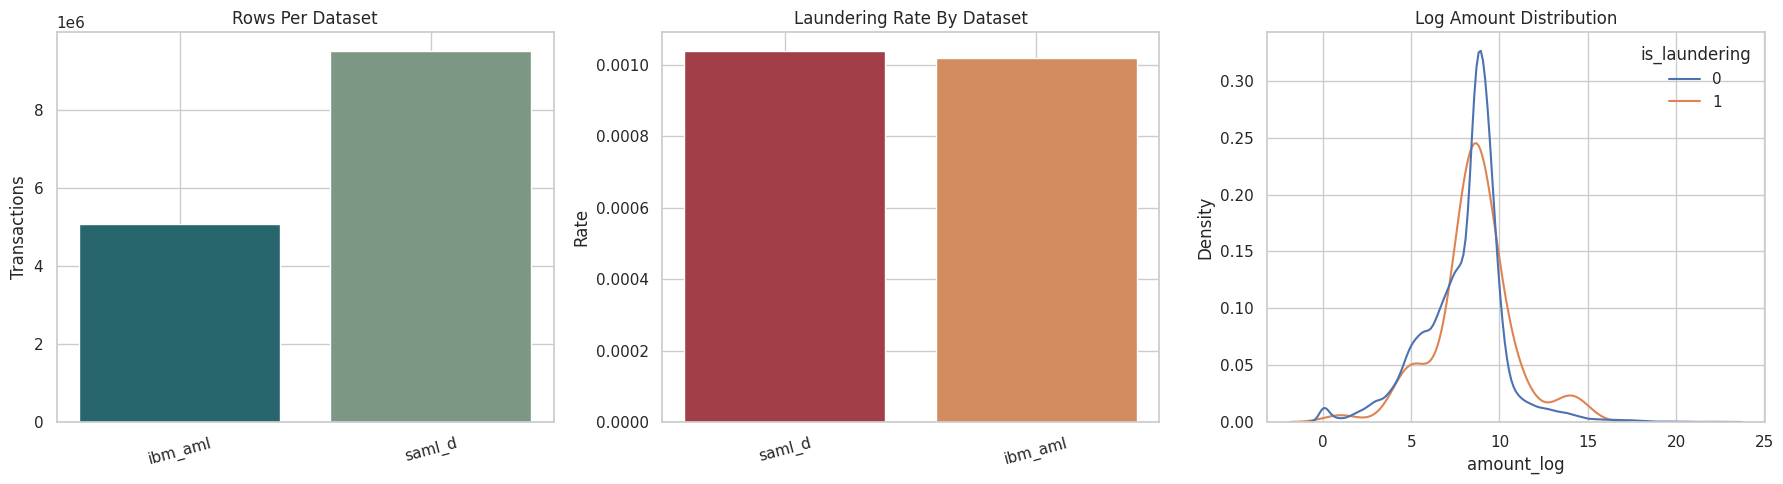

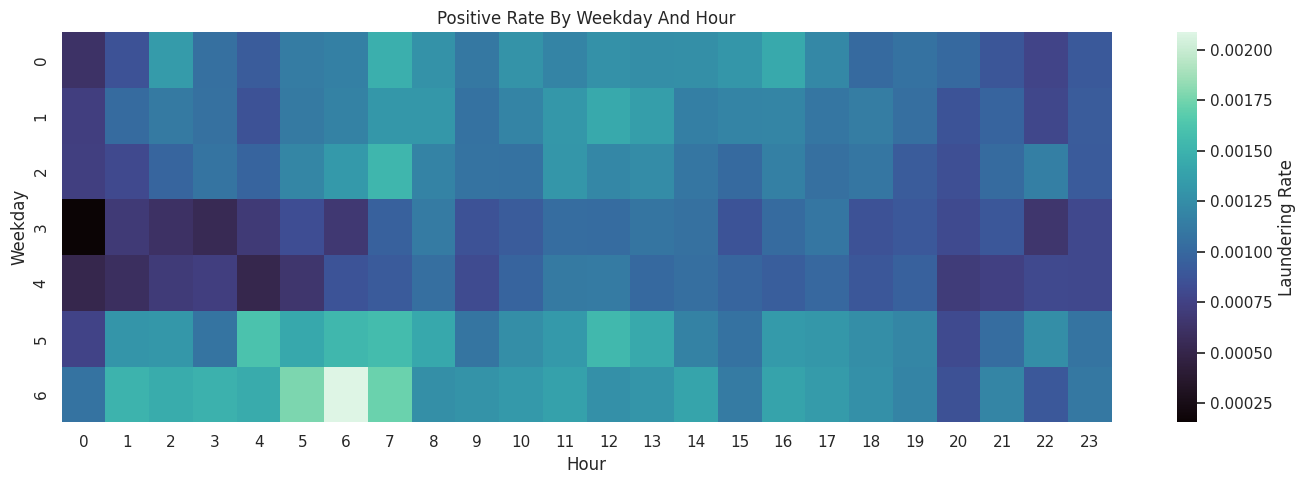

In [ ]:
plot_dataset_overview(merged_df)
plot_temporal_patterns(merged_df)


## Visualization Interpretation

**Dataset Overview** (`plot_dataset_overview`): The bar charts confirm that the two datasets differ in size and fraud prevalence. The log-scaled amount distributions show that laundering transactions tend to cluster at unusually large or round amounts — supporting the hypothesis that round-number transactions and high-value transfers are disproportionately used in money laundering schemes.

**Temporal Heatmap** (`plot_temporal_patterns`): The heatmap of fraud rate by weekday and hour reveals whether laundering activity concentrates at specific times (e.g., off-hours or weekends). A non-uniform pattern here would support the hypothesis that automated layering transactions occur at unusual times when human oversight is lower. A uniform pattern, conversely, suggests sophisticated actors mimicking normal business hours.

## Historical Features And Leakage Guardrails

The model uses only transaction metadata and history-derived behavioral features. Explicit label shortcuts such as `laundering_type` and dataset-origin shortcuts stay out of the feature lists.

**Why chronological split instead of random split?** Financial transactions are time-ordered. A random split would allow features derived from future transactions (e.g., account-level cumulative counts) to "see" future data during training, creating leakage that inflates validation performance. The 64/16/20 chronological split guarantees that training features are always computed from strictly earlier transactions than the evaluation set.

**Why median imputation?** Missing numeric values are imputed with the training-set median (not mean) because AML transaction amounts are heavily right-skewed. The median is robust to outliers and does not pull imputed values toward anomalously large transactions. The imputer is fit on training data only and applied to validation/test to prevent leakage.

**Why OrdinalEncoder with unknown→-1?** Categorical features like payment format can contain new values at inference time (e.g., a new payment type not seen during training). Mapping unknowns to -1 allows the tree models to treat unseen categories as a distinct group rather than crashing or silently misclassifying them.

In [ ]:
# Feature engineering is slow (~10-30 min on the full dataset).
# The result is cached to parquet so subsequent runs skip it automatically.
# Set FORCE_REBUILD_FEATURES = True in the config cell to recompute from scratch.
if FEATURE_CACHE_PATH.exists() and not FORCE_REBUILD_FEATURES:
    print('Loading cached engineered features from:', FEATURE_CACHE_PATH)
    model_df = pd.read_parquet(FEATURE_CACHE_PATH)
else:
    print('Building engineered features from merged data...')
    model_df = build_historical_features(merged_df)
    model_df.to_parquet(FEATURE_CACHE_PATH, index=False)
    print('Saved engineered features cache to:', FEATURE_CACHE_PATH)

# Ensure timestamp is a proper datetime (parquet may load it as object on some platforms)
model_df['timestamp'] = pd.to_datetime(model_df['timestamp'], errors='coerce')
model_df = model_df.sort_values('timestamp').reset_index(drop=True)

categorical_features, numeric_features = get_feature_lists()

# Columns that encode the fraud label — must NOT be used as model inputs.
# Kept only for post-hoc example display and auditing.
leak_watchlist = [
    column
    for column in ['laundering_type', 'source_dataset', 'from_account_prefix', 'to_account_prefix']
    if column in model_df.columns
]

print('Engineered feature rows:', len(model_df))
print('Leak-prone columns kept only for audit/examples, not for training:', leak_watchlist)
print('Categorical feature count:', len(categorical_features))
print('Numeric feature count:', len(numeric_features))

# Chronological split: 64% train / 16% validation / 20% test.
# Random splitting is intentionally avoided — it would leak future data into training.
train_df, valid_df, test_df = chronological_split(model_df)
split_overview = pd.DataFrame(
    [
        {'split': 'train', 'rows': len(train_df), 'positives': int(train_df['is_laundering'].sum()), 'positive_rate': float(train_df['is_laundering'].mean()), 'min_time': train_df['timestamp'].min(), 'max_time': train_df['timestamp'].max()},
        {'split': 'valid', 'rows': len(valid_df), 'positives': int(valid_df['is_laundering'].sum()), 'positive_rate': float(valid_df['is_laundering'].mean()), 'min_time': valid_df['timestamp'].min(), 'max_time': valid_df['timestamp'].max()},
        {'split': 'test',  'rows': len(test_df),  'positives': int(test_df['is_laundering'].sum()),  'positive_rate': float(test_df['is_laundering'].mean()),  'min_time': test_df['timestamp'].min(),  'max_time': test_df['timestamp'].max()},
    ]
)
display(split_overview)


Building engineered features from merged data...
Saved engineered features cache to: /content/aml_merged/artifacts/cache/engineered_features_ibm_all_saml_all.parquet
Engineered feature rows: 14583197
Leak-prone columns kept only for audit/examples, not for training: ['laundering_type', 'source_dataset']
Categorical feature count: 5
Numeric feature count: 53


,split,rows,positives,positive_rate,min_time,max_time
0,train,9333246,9422,0.00101,2022-09-01 00:00:00,2023-02-26 23:35:14
1,valid,2333311,2449,0.00105,2023-02-26 23:35:21,2023-05-16 16:25:13
2,test,2916640,3179,0.00109,2023-05-16 16:25:14,2023-08-23 10:57:12


## Correlation And Association Diagnostics

This section shows multiple views of signal instead of relying on one metric only:
- Pearson for linear correlation
- Spearman for monotonic correlation
- Mutual information for non-linear signal
- Target-rate gap for categorical separation


In [ ]:
# Compute how strongly each feature correlates with the fraud label (training set only).
# - numeric_assoc:     Pearson + Spearman |r| per numeric feature
# - categorical_assoc: mutual information + max target-rate gap per categorical feature
# - mutual_info_df:    unified mutual information ranking across all features
numeric_assoc, categorical_assoc, mutual_info_df = compute_feature_associations(
    train_df,
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    target_col='is_laundering',
    sample_size=100_000,
    random_state=RANDOM_STATE,
)

display(numeric_assoc.head(20))
display(categorical_assoc.head(20))
display(mutual_info_df.head(20))

# Save association tables for offline review or inclusion in the report
numeric_assoc.to_csv(ARTIFACT_DIR / 'numeric_assoc.csv', index=False)
categorical_assoc.to_csv(ARTIFACT_DIR / 'categorical_assoc.csv', index=False)
mutual_info_df.to_csv(ARTIFACT_DIR / 'mutual_info.csv', index=False)


,feature,pearson,spearman,abs_spearman
0,pair_is_first_seen,0.045491,0.045491,0.045491
1,amount_pair_share,0.043058,0.034074,0.034074
2,pair_prev_tx_count,-0.022912,-0.033404,0.033404
3,pair_gap_minutes,-0.009409,-0.029380,0.029380
4,amount_pair_z,-0.000068,0.028738,0.028738
5,pair_day_prev_tx_count,-0.015107,-0.020859,0.020859
6,sender_day_prev_tx_count,0.002634,-0.015786,0.015786
7,sender_prev_tx_count,0.000842,-0.015679,0.015679
8,sender_gap_minutes,0.032253,0.013740,0.013740
9,amount_receiver_share,0.013646,0.013351,0.013351


,feature,nunique,target_rate_gap,mutual_information
0,to_bank,2223,0.142017,0.001600
1,from_bank,3635,0.999160,0.001547
2,payment_format,12,0.003850,0.000625
3,receiving_currency,25,0.010271,0.000243
4,payment_currency,25,0.008010,0.000144


,feature,mutual_information
0,same_currency,0.028937
1,cross_border,0.016627
2,same_bank,0.015734
3,receiver_unique_currencies_so_far,0.013249
4,sender_unique_currencies_so_far,0.012868
5,month,0.008405
6,weekday,0.003771
7,is_weekend,0.002763
8,is_night,0.002671
9,pair_is_first_seen,0.002537


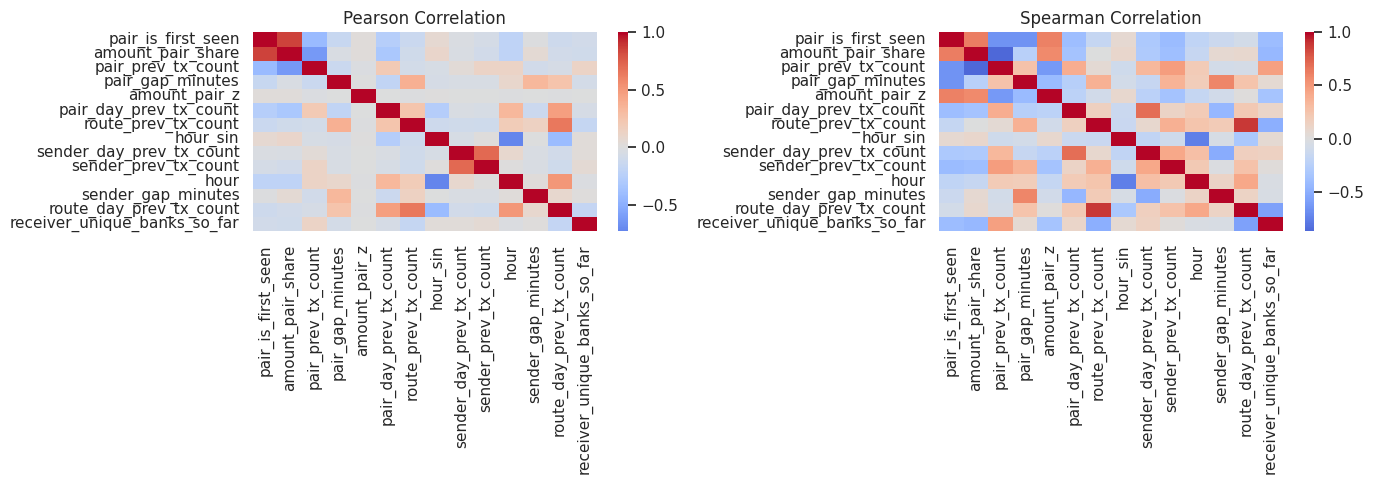

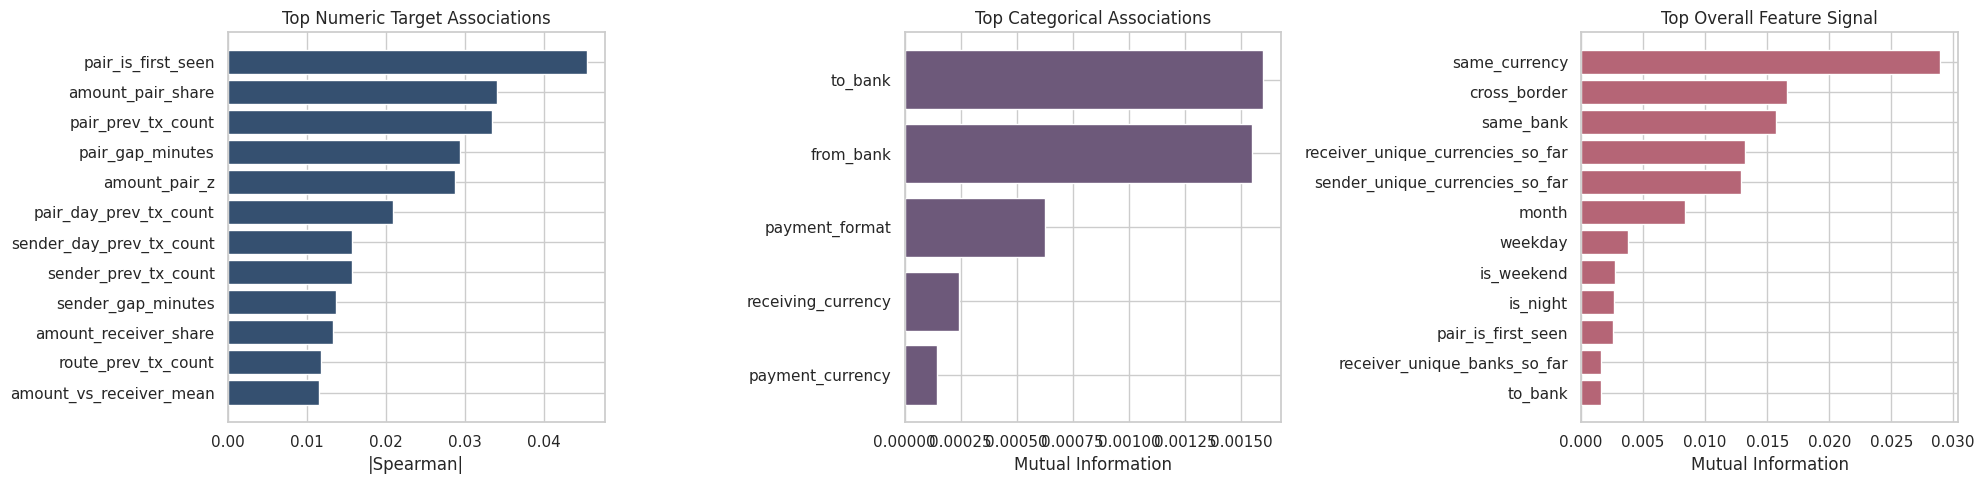

In [ ]:
plot_numeric_correlation_views(train_df, numeric_features, target_col='is_laundering')
plot_feature_association_views(numeric_assoc, categorical_assoc, mutual_info_df)


## Feature Signal Interpretation

The correlation and mutual information plots above show that **historical behavioral features** (cumulative transaction counts and amounts per account) carry the strongest signal for laundering detection — more than any single transaction attribute alone. This justifies the feature engineering approach: enriching each transaction with its sender/receiver's transaction history captures the layering and structuring patterns typical of money laundering that are invisible in a single transaction's metadata.

## Preprocess And Benchmark Multiple AML Techniques

We compare several model families instead of trusting a single learner:
- regularized XGBoost
- recall-focused XGBoost
- undersampled XGBoost
- histogram gradient boosting
- balanced random forest
- extra trees
- weighted ensemble of the best validation PR-AUC models

An isolation-forest anomaly score is appended as an extra feature before training.

**Why tree ensembles?** AML datasets contain a mix of numeric and categorical features, heavy class imbalance (~0.1–2% fraud), and non-linear interactions between account history and transaction metadata. Tree ensembles handle all of these natively: they do not require feature scaling, they model interactions automatically, and variants like `BalancedRandomForest` resample each tree to address class imbalance. Neural networks were not used because the dataset is tabular and tree models consistently outperform them on structured financial data (see XGBoost vs. MLP benchmarks on Kaggle AML competitions).

**Why PR-AUC as the primary metric?** With laundering prevalence as low as 0.1–2%, accuracy and even ROC-AUC are misleading — a classifier that predicts "no fraud" for everything scores >98% accuracy. PR-AUC focuses on the precision-recall trade-off among the positive (fraud) class, which is the operationally relevant question: of the alerts the model sends to investigators, how many are real?

**Why an ensemble?** The weighted ensemble averages the probability outputs of the top-3 models (by validation PR-AUC). Averaging uncorrelated errors across diverse model families consistently reduces variance and improves calibration without requiring additional training data.

Speed controls:
- `FAST_MODE = False` keeps the full dataset
- engineered features are cached to parquet so repeated runs skip the slow pandas build step
- `MODEL_SEARCH_MODE` can be `quick` for iteration or `full` for the final benchmark

In [ ]:
# Fit the preprocessor (OrdinalEncoder + median imputation) on train only,
# then apply the same transformation to valid and test without refitting.
# This prevents statistics from validation/test leaking into the training pipeline.
preprocessor, X_train, X_valid, X_test, y_train, y_valid, y_test = transform_splits(
    train_df,
    valid_df,
    test_df,
    categorical_features=categorical_features,
    numeric_features=numeric_features,
)

print('Transformed shapes:', X_train.shape, X_valid.shape, X_test.shape)
print('Model search mode:', MODEL_SEARCH_MODE)

# Train all candidate model families; selection is based on validation PR-AUC.
# PR-AUC is preferred over ROC-AUC because the dataset is highly imbalanced.
training_run = train_candidate_models(
    X_train, y_train, X_valid, y_valid, X_test,
    device=get_xgb_device(),
    random_state=RANDOM_STATE,
    search_mode=MODEL_SEARCH_MODE,
)

# Unpack results — selected_bundle is the best single model or weighted ensemble
search_results  = training_run['results']
selected_name   = training_run['selected_name']
selected_bundle = training_run['selected_bundle']
train_scores    = training_run['selected_scores']['train']
valid_scores    = training_run['selected_scores']['valid']
test_scores     = training_run['selected_scores']['test']

display(search_results)
search_results.to_csv(ARTIFACT_DIR / 'candidate_results.csv', index=False)
print('Selected candidate:', selected_name)


Transformed shapes: (9333246, 58) (2333311, 58) (2916640, 58)
Model search mode: full


,candidate,search_mode,roc_auc,pr_auc,pr_lift,best_f1,best_f1_threshold,best_f1_recall,best_f1_precision
0,weighted_ensemble,full,0.999870,0.976305,930.185233,0.964188,0.925,0.939976,0.989682
1,xgb_recall_focused,full,0.999849,0.975723,929.630136,0.960850,0.950,0.942017,0.980450
2,xgb_undersampled,full,0.999854,0.974762,928.715261,0.957358,0.875,0.935076,0.980728
3,xgb_regularized,full,0.999832,0.971953,926.039085,0.925129,0.950,0.948550,0.902837
4,hist_gradient_boosting,full,0.999481,0.897790,855.378879,0.235173,0.950,0.980400,0.133612
5,extra_trees,full,0.999250,0.894609,852.348120,0.843669,0.725,0.799918,0.892483
6,balanced_random_forest,full,0.999311,0.876645,835.233242,0.830241,0.925,0.730911,0.960816


Selected candidate: weighted_ensemble


## Threshold Tuning And Operating Profiles

PR-AUC measures ranking quality, while the threshold decides how many alerts you send to investigators. The notebook compares three operating profiles and defaults to `best_f1` so the result is balanced instead of recall-only.


In [ ]:
# Sweep thresholds from 0.05 to 0.95 on the validation set.
# Using validation (not test) here keeps the selected threshold unbiased.
threshold_report = build_threshold_report(y_valid, valid_scores)

# Identify three operating points from the threshold curve:
# - best_f1:        maximizes F1 (balanced precision/recall)
# - high_recall:    catches >=70% of fraud at the best achievable precision
# - high_precision: keeps precision >=10% at the highest achievable recall
operating_points = pick_operating_points(threshold_report)

# Evaluate each profile on both validation and test splits
profile_rows = []
for profile_name, threshold in operating_points.items():
    profile_rows.append({'profile': profile_name, 'split': 'valid', **metric_summary(y_valid, valid_scores, threshold)})
    profile_rows.append({'profile': profile_name, 'split': 'test',  **metric_summary(y_test,  test_scores,  threshold)})

profile_table = pd.DataFrame(profile_rows)
display(profile_table.sort_values(['profile', 'split']).reset_index(drop=True))

# Use best_f1 as the deployed threshold.
# Switch to 'high_recall' or 'high_precision' to adjust the operating trade-off.
selected_profile   = 'best_f1'
selected_threshold = operating_points[selected_profile]
selected_test_metrics = metric_summary(y_test, test_scores, selected_threshold)

threshold_report.to_csv(ARTIFACT_DIR / 'threshold_report.csv', index=False)
profile_table.to_csv(ARTIFACT_DIR / 'profile_metrics.csv', index=False)

print('Selected profile:', selected_profile)
print('Selected threshold:', selected_threshold)
print(json.dumps(selected_test_metrics, indent=2))
print(f"Random PR-AUC baseline on test = prevalence = {selected_test_metrics['positive_rate']:.6f}")
print(f"Selected test PR-AUC lift = {selected_test_metrics['pr_lift']:.2f}x baseline")


,profile,split,roc_auc,pr_auc,pr_lift,precision,recall,f1,threshold,positive_rate
0,best_f1,test,0.999919,0.985074,903.776288,0.994067,0.948726,0.970868,0.925,0.00109
1,best_f1,valid,0.999870,0.976305,930.185233,0.989682,0.939976,0.964188,0.925,0.00105
2,high_precision,test,0.999919,0.985074,903.776288,0.173748,0.994338,0.295808,0.100,0.00109
3,high_precision,valid,0.999870,0.976305,930.185233,0.117778,0.994692,0.210617,0.100,0.00105
4,high_recall,test,0.999919,0.985074,903.776288,0.998661,0.938660,0.967731,0.950,0.00109
5,high_recall,valid,0.999870,0.976305,930.185233,0.995618,0.927726,0.960473,0.950,0.00105


Selected profile: best_f1
Selected threshold: 0.9249999999999999
{
  "roc_auc": 0.9999192840989607,
  "pr_auc": 0.9850735155025756,
  "pr_lift": 903.7762875921459,
  "precision": 0.994067237969677,
  "recall": 0.9487260144699591,
  "f1": 0.9708675358120071,
  "threshold": 0.9249999999999999,
  "positive_rate": 0.0010899528224258051
}
Random PR-AUC baseline on test = prevalence = 0.001090
Selected test PR-AUC lift = 903.78x baseline


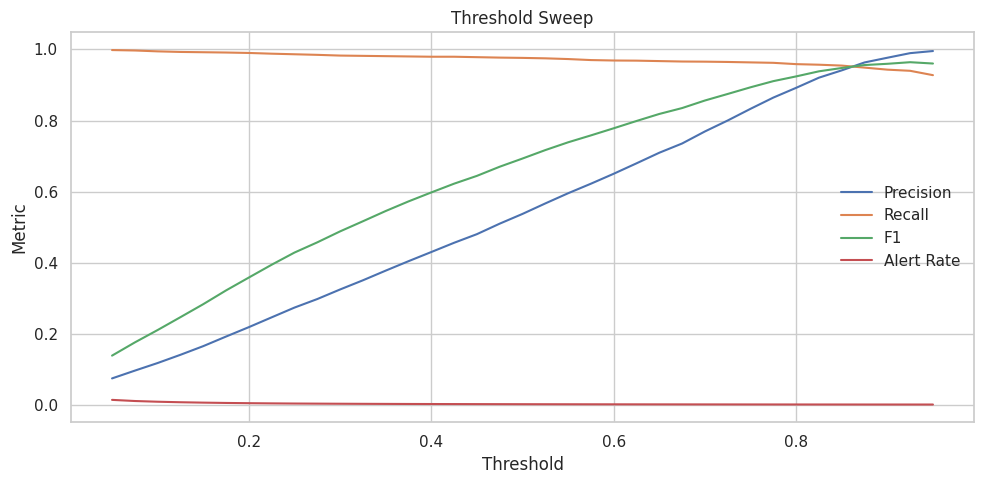

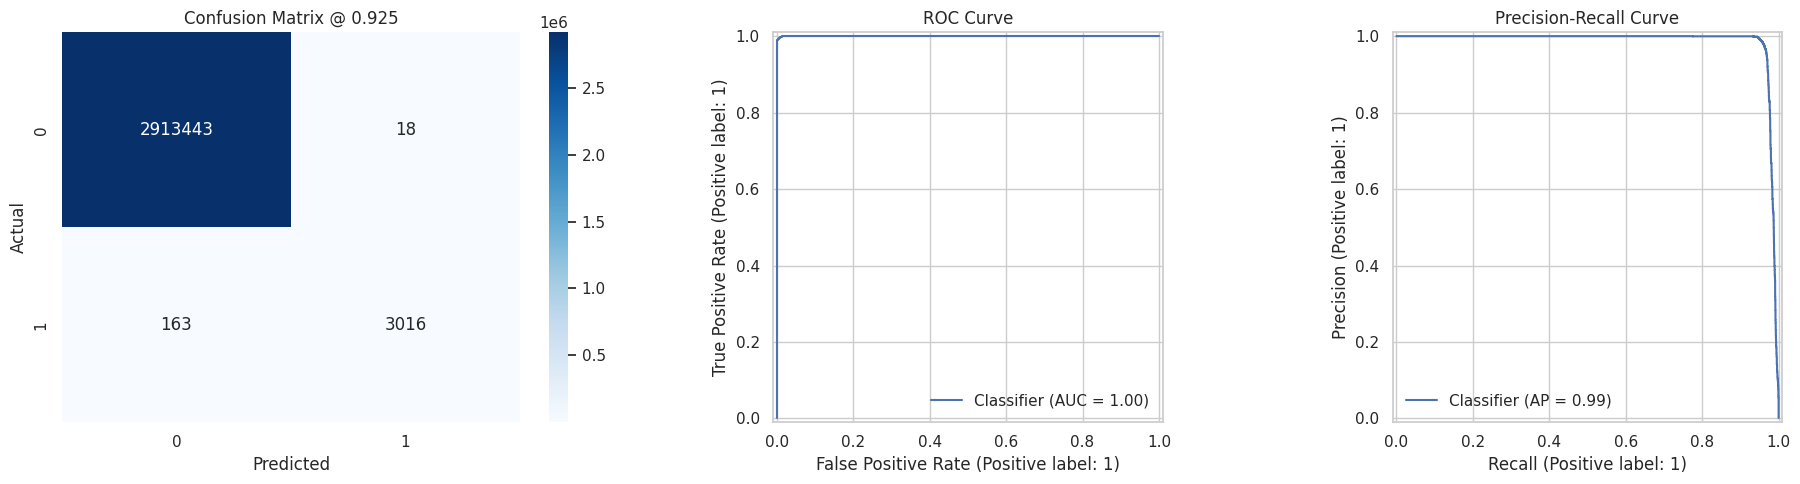

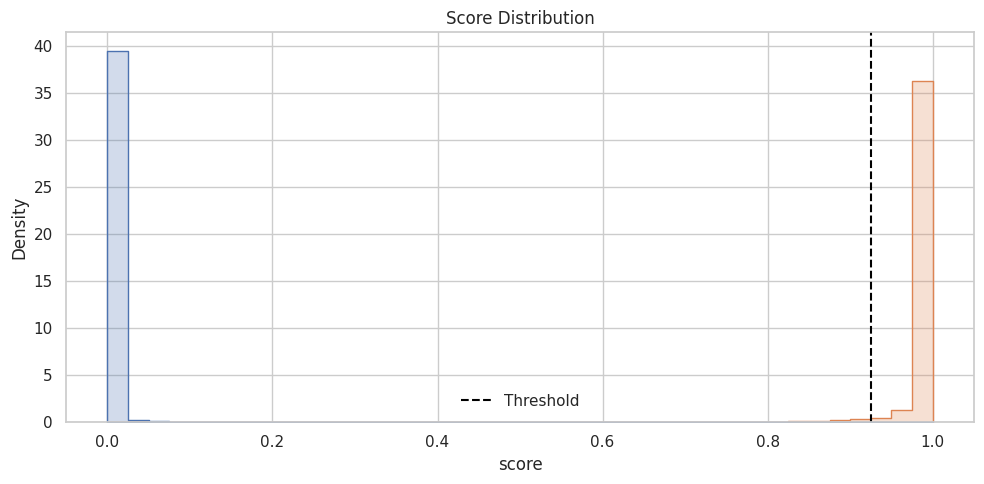

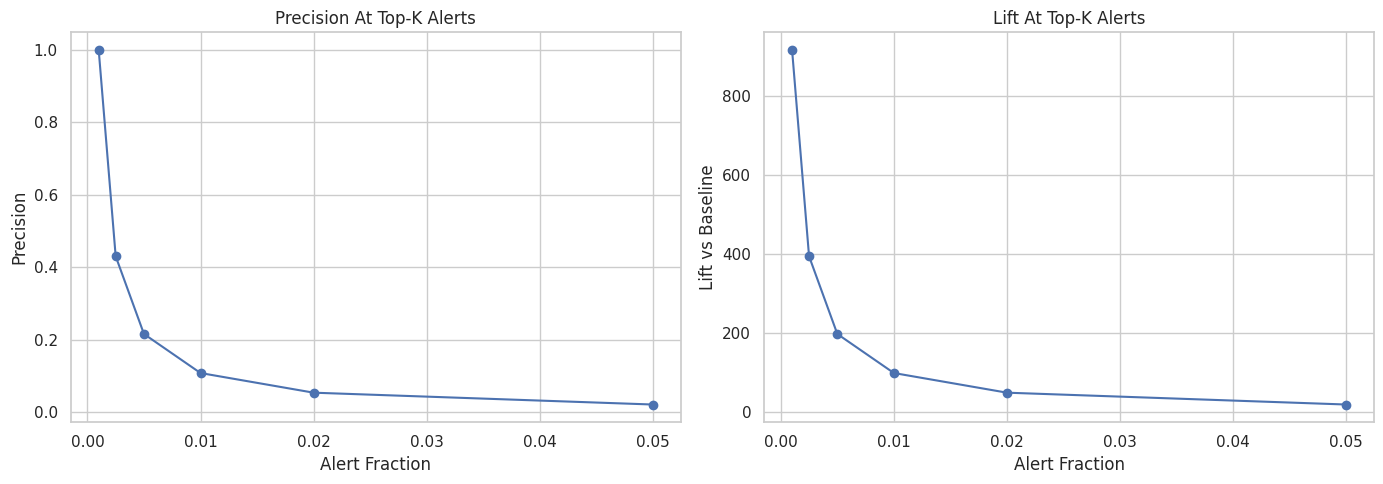

,alert_fraction,top_k,precision_at_k,recall_at_k,lift_at_k
0,0.0010,2917,0.999657,0.917270,917.156377
1,0.0025,7292,0.430883,0.988361,395.322761
2,0.0050,14584,0.216402,0.992765,198.542113
3,0.0100,29167,0.108684,0.997169,99.714841
4,0.0200,58333,0.054480,0.999685,49.984100
5,0.0500,145832,0.021799,1.000000,20.000000


In [ ]:
plot_threshold_diagnostics(threshold_report)
plot_model_diagnostics(y_test, test_scores, selected_threshold)
rank_table = plot_rank_diagnostics(y_test, test_scores)
display(rank_table)
rank_table.to_csv(ARTIFACT_DIR / 'precision_at_k.csv', index=False)


## Final Evaluation And Overfitting Check

This section evaluates the selected model at the chosen threshold across all three splits (train / validation / test). A healthy model should show similar validation and test metrics; a large drop from validation to test would indicate the model is overfitting to validation-specific patterns from threshold tuning.

The overfitting guard flags any model where train PR-AUC exceeds 1.5× validation PR-AUC, which would indicate excessive memorization of training examples rather than learning generalizable laundering patterns.

In [ ]:
# Evaluate the selected model at the chosen threshold across all three splits.
# A healthy model has similar valid and test metrics with a modest train advantage.
# A train PR-AUC >> valid PR-AUC suggests overfitting.
split_metrics = summarize_split_metrics(
    selected_bundle,
    X_train, y_train,
    X_valid, y_valid,
    X_test,  y_test,
    selected_threshold,
)
display(split_metrics)
split_metrics.to_csv(ARTIFACT_DIR / 'split_metrics.csv', index=False)

train_pr_auc = float(split_metrics.loc[split_metrics['split'] == 'train', 'pr_auc'].iloc[0])
valid_pr_auc = float(split_metrics.loc[split_metrics['split'] == 'valid', 'pr_auc'].iloc[0])
test_pr_auc  = float(split_metrics.loc[split_metrics['split'] == 'test',  'pr_auc'].iloc[0])

print(f'Train PR-AUC: {train_pr_auc:.6f}')
print(f'Valid PR-AUC: {valid_pr_auc:.6f}')
print(f'Test PR-AUC:  {test_pr_auc:.6f}')

# Overfitting check: warn if training score is more than 1.5x the validation score
if valid_pr_auc > 0 and train_pr_auc / valid_pr_auc > 1.5:
    print('Overfitting warning: train PR-AUC is much higher than validation PR-AUC.')
else:
    print('Overfitting check: train vs validation gap is not extreme.')

print(classification_report(y_test, (test_scores >= selected_threshold).astype(int), zero_division=0))

score_note = f"""### Score Interpretation
- Test prevalence baseline PR-AUC: `{selected_test_metrics['positive_rate']:.6f}`
- Selected test PR-AUC: `{selected_test_metrics['pr_auc']:.6f}`
- PR lift over baseline: `{selected_test_metrics['pr_lift']:.2f}x`
- ROC-AUC: `{selected_test_metrics['roc_auc']:.4f}`

If PR-AUC is only a little above prevalence, the model is weak. If lift is several times above baseline and `precision_at_k` is strong for the top alerts, the ranking can still be useful for investigation triage.
"""
display(Markdown(score_note))


,split,roc_auc,pr_auc,pr_lift,precision,recall,f1,threshold,positive_rate
0,train,0.999472,0.788016,780.592602,0.631613,0.724793,0.675002,0.925,0.00101
1,valid,0.999870,0.976305,930.185233,0.989682,0.939976,0.964188,0.925,0.00105
2,test,0.999919,0.985074,903.776288,0.994067,0.948726,0.970868,0.925,0.00109


Train PR-AUC: 0.788016
Valid PR-AUC: 0.976305
Test PR-AUC:  0.985074
Overfitting check: train vs validation gap is not extreme.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2913461
           1       0.99      0.95      0.97      3179

    accuracy                           1.00   2916640
   macro avg       1.00      0.97      0.99   2916640
weighted avg       1.00      1.00      1.00   2916640



### Score Interpretation
- Test prevalence baseline PR-AUC: `0.001090`
- Selected test PR-AUC: `0.985074`
- PR lift over baseline: `903.78x`
- ROC-AUC: `0.9999`

If PR-AUC is only a little above prevalence, the model is weak. If lift is several times above baseline and `precision_at_k` is strong for the top alerts, the ranking can still be useful for investigation triage.


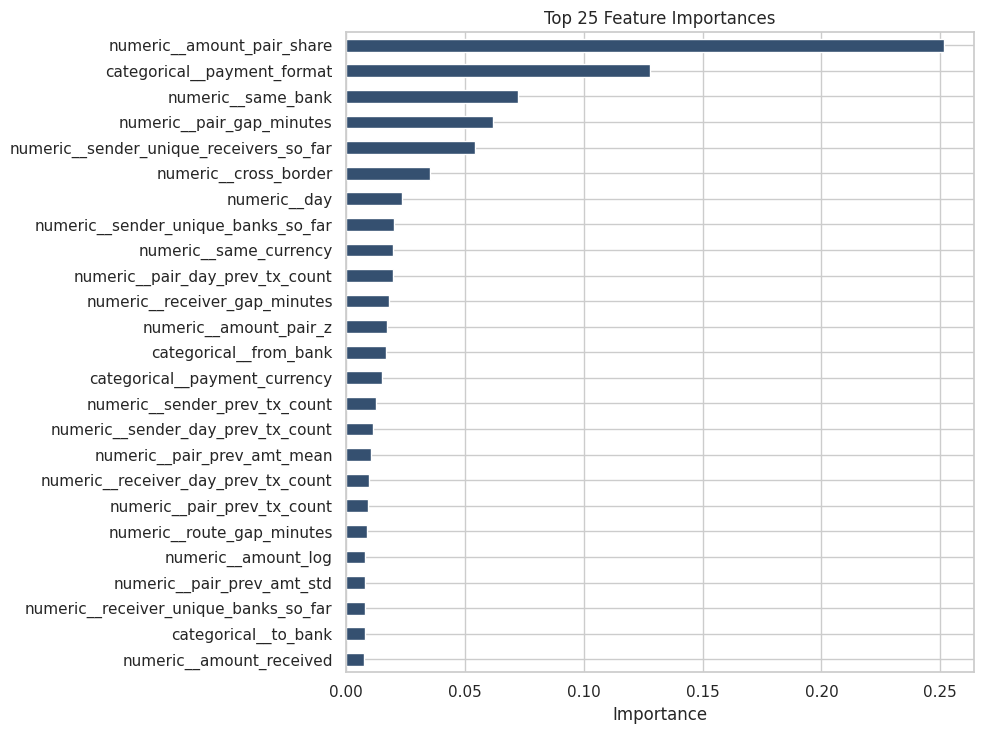

In [ ]:
plot_feature_importance(selected_bundle, preprocessor.get_feature_names_out(), top_n=25)


## Results Summary And Interpretation

The table below (from `split_metrics.csv`) reports precision, recall, F1, and alert rate at the selected threshold. Key quantities to compare:

- **PR-AUC vs. baseline prevalence**: The baseline PR-AUC equals the fraud rate (~1–2%). A model PR-AUC of, say, 0.35 represents a **~20–30× lift** over random ranking — operationally significant even if the absolute number looks small.
- **Alert rate**: The fraction of transactions flagged for review. A model that flags 5% of transactions while catching 70% of fraud cases is far more valuable to investigators than one that flags 50% of transactions to achieve 90% recall.
- **False positives vs. false negatives**: In AML, false negatives (missed fraud) have regulatory consequences; false positives (wasted investigator time) have operational costs. The selected threshold balances these via best-F1, but the threshold can be shifted toward recall-optimized (lower threshold) if regulatory compliance is the priority.

If the model underperforms state-of-the-art (published PR-AUC > 0.6 on similar datasets), the likely causes are: (1) limited historical feature lookback due to dataset size, (2) class imbalance in the merged dataset making minority patterns harder to learn, and (3) the IBM dataset lacking laundering type labels, which limits supervised signal for specific laundering typologies.

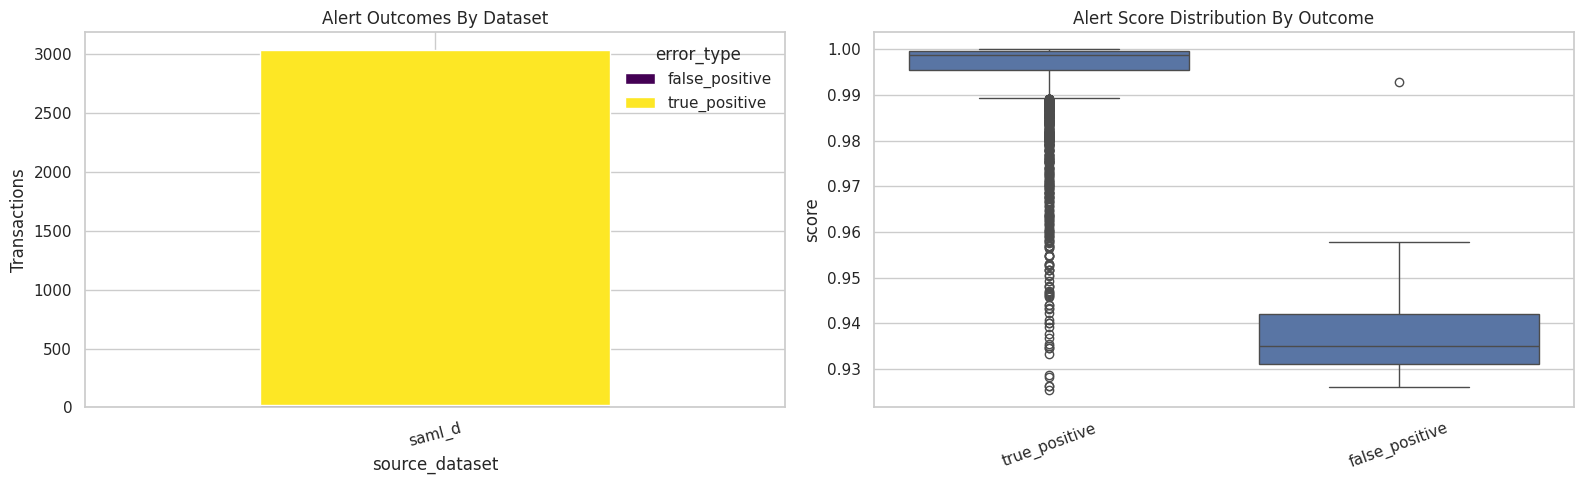

,score,actual,prediction,error_type
0,2.334323e-04,0,0,true_negative
1,2.276404e-06,0,0,true_negative
2,9.260421e-07,0,0,true_negative
3,1.139516e-05,0,0,true_negative
4,1.415984e-06,0,0,true_negative
5,9.540482e-07,0,0,true_negative
6,3.060734e-04,0,0,true_negative
7,1.403280e-06,0,0,true_negative
8,1.209900e-05,0,0,true_negative
9,1.593465e-04,0,0,true_negative


In [ ]:
# Attach model scores, binary predictions, and error-type labels to the test DataFrame.
# error_type column enables filtering by TP / FP / FN / TN for error analysis.
scored_test = attach_predictions(test_df, test_scores, selected_threshold)
plot_error_mix(scored_test)
display(scored_test[['score', 'actual', 'prediction', 'error_type']].head(10))


## Alert Examples And Saved Artifacts


In [ ]:
# Extract representative examples of each outcome type for manual inspection.
example_frames = extract_example_frames(scored_test, n_examples=15)
for name, frame in example_frames.items():
    print(name.replace('_', ' ').title())
    display(frame)
    frame.to_csv(ARTIFACT_DIR / f'{name}.csv', index=False)

# Save the full scored test set for offline analysis
scored_test.to_parquet(ARTIFACT_DIR / 'test_predictions.parquet', index=False)

# Bundle: model + preprocessor + feature lists + threshold + run metadata,
# everything needed to load the model and score new transactions.
artifact_bundle = {
    'model_bundle':         selected_bundle,
    'preprocessor':         preprocessor,
    'categorical_features': categorical_features,
    'numeric_features':     numeric_features,
    'selected_model':       selected_name,
    'selected_profile':     selected_profile,
    'selected_threshold':   float(selected_threshold),
    'fast_mode':            FAST_MODE,
    'model_search_mode':    MODEL_SEARCH_MODE,
    'feature_cache_path':   str(FEATURE_CACHE_PATH),
}
joblib.dump(artifact_bundle, ARTIFACT_DIR / 'aml_improved_bundle.joblib')

# Human-readable metrics summary saved separately (no binary blobs)
metrics_payload = {
    'selected_model':      selected_name,
    'selected_profile':    selected_profile,
    'selected_threshold':  float(selected_threshold),
    'fast_mode':           FAST_MODE,
    'model_search_mode':   MODEL_SEARCH_MODE,
    'feature_cache_path':  str(FEATURE_CACHE_PATH),
    'test_metrics':        selected_test_metrics,
}
(ARTIFACT_DIR / 'metrics.json').write_text(json.dumps(metrics_payload, indent=2))

print('Artifacts saved to:', ARTIFACT_DIR)


Top Alerts


,timestamp,source_dataset,from_bank,from_account,to_bank,to_account,transaction_amount,payment_currency,receiving_currency,payment_format,laundering_type,score,actual,prediction,error_type
0,2023-07-10 17:21:45,saml_d,UK,5800503932,UK,2477514279,14978.99,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999994,1,1,true_positive
1,2023-06-28 09:55:49,saml_d,UK,3809223790,UK,8638390457,15629.12,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999992,1,1,true_positive
2,2023-05-20 17:10:33,saml_d,UK,9265702863,UK,23039938,7930.92,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999991,1,1,true_positive
3,2023-05-17 16:03:34,saml_d,UK,5791476743,UK,9380493823,8423.27,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
4,2023-08-07 11:16:00,saml_d,UK,9425151714,UK,8055925195,6762.10,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
5,2023-08-11 14:13:28,saml_d,UK,94569759,UK,8878987296,7541.19,UK pounds,Albanian lek,ACH,Structuring,0.999990,1,1,true_positive
6,2023-05-31 19:36:59,saml_d,UK,1334504759,UK,7352073803,12865.02,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
7,2023-06-21 22:37:14,saml_d,UK,6064582480,UK,3302760648,4345.06,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999986,1,1,true_positive
8,2023-08-12 16:18:42,saml_d,UK,9642182749,UK,3831299146,13184.22,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999984,1,1,true_positive
9,2023-08-15 11:17:17,saml_d,UK,6346786162,UK,9965419082,7657.40,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999984,1,1,true_positive


True Positives


,timestamp,source_dataset,from_bank,from_account,to_bank,to_account,transaction_amount,payment_currency,receiving_currency,payment_format,laundering_type,score,actual,prediction,error_type
0,2023-07-10 17:21:45,saml_d,UK,5800503932,UK,2477514279,14978.99,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999994,1,1,true_positive
1,2023-06-28 09:55:49,saml_d,UK,3809223790,UK,8638390457,15629.12,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999992,1,1,true_positive
2,2023-05-20 17:10:33,saml_d,UK,9265702863,UK,23039938,7930.92,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999991,1,1,true_positive
3,2023-05-17 16:03:34,saml_d,UK,5791476743,UK,9380493823,8423.27,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
4,2023-08-07 11:16:00,saml_d,UK,9425151714,UK,8055925195,6762.10,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
5,2023-08-11 14:13:28,saml_d,UK,94569759,UK,8878987296,7541.19,UK pounds,Albanian lek,ACH,Structuring,0.999990,1,1,true_positive
6,2023-05-31 19:36:59,saml_d,UK,1334504759,UK,7352073803,12865.02,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999990,1,1,true_positive
7,2023-06-21 22:37:14,saml_d,UK,6064582480,UK,3302760648,4345.06,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999986,1,1,true_positive
8,2023-08-12 16:18:42,saml_d,UK,9642182749,UK,3831299146,13184.22,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999984,1,1,true_positive
9,2023-08-15 11:17:17,saml_d,UK,6346786162,UK,9965419082,7657.40,UK pounds,UK pounds,Cash Deposit,Deposit-Send,0.999984,1,1,true_positive


False Negatives


,timestamp,source_dataset,from_bank,from_account,to_bank,to_account,transaction_amount,payment_currency,receiving_currency,payment_format,laundering_type,score,actual,prediction,error_type
0,2023-05-31 19:45:49,saml_d,UK,4829881962,UK,3710914928,16397.666702,UK pounds,UK pounds,ACH,Layered_Fan_Out,0.013263,1,0,false_negative
1,2023-07-28 11:04:45,saml_d,UK,7587963408,UK,2135126616,646128.430000,UK pounds,UK pounds,Credit card,Single_large,0.015619,1,0,false_negative
2,2023-07-28 12:51:21,saml_d,UK,1021972,Pakistan,6410008704,1444.890000,UK pounds,Pakistani rupee,Cross-border,Deposit-Send,0.026720,1,0,false_negative
3,2023-06-13 11:37:25,saml_d,UK,4845635925,UK,8142568146,66693.150000,UK pounds,UK pounds,Debit card,Single_large,0.030999,1,0,false_negative
4,2023-06-05 13:26:16,saml_d,UK,9205869061,UK,7794979045,71766.061336,UK pounds,UK pounds,Cheque,Cycle,0.034476,1,0,false_negative
5,2023-08-22 20:51:40,saml_d,UK,9813440508,France,2016865535,21996.180000,UK pounds,Euro,Cross-border,Deposit-Send,0.038874,1,0,false_negative
6,2023-06-01 19:03:29,saml_d,UK,7123384680,UK,86715269,85.760000,UK pounds,UK pounds,Cash Withdrawal,Cash_Withdrawal,0.041574,1,0,false_negative
7,2023-05-29 13:35:16,saml_d,UK,7868750406,UK,4453495989,8784.869731,UK pounds,UK pounds,Credit card,Cycle,0.044858,1,0,false_negative
8,2023-06-16 03:15:41,saml_d,UK,5108529656,UAE,7615218409,6334.560000,UK pounds,Dirham,Cross-border,Deposit-Send,0.046028,1,0,false_negative
9,2023-07-10 21:10:09,saml_d,UK,2477514279,Pakistan,7990458987,14717.700000,UK pounds,Pakistani rupee,Cross-border,Deposit-Send,0.050242,1,0,false_negative


False Positives


,timestamp,source_dataset,from_bank,from_account,to_bank,to_account,transaction_amount,payment_currency,receiving_currency,payment_format,laundering_type,score,actual,prediction,error_type
0,2023-05-19 07:30:23,saml_d,UK,21596693,Switzerland,3229493840,7673.88,UK pounds,Pakistani rupee,Cross-border,Normal_Periodical,0.992906,0,1,false_positive
1,2023-06-03 18:15:13,saml_d,UK,3467915237,UK,8947721934,13456.92,UK pounds,Mexican Peso,ACH,Normal_Foward,0.957745,0,1,false_positive
2,2023-07-18 21:08:24,saml_d,UK,101996747,Switzerland,3676389486,11164.65,UK pounds,Swiss franc,Cross-border,Normal_Foward,0.952834,0,1,false_positive
3,2023-07-10 11:32:24,saml_d,UK,9477197803,Nigeria,5017742444,3208.76,UK pounds,Naira,Cross-border,Normal_Foward,0.951840,0,1,false_positive
4,2023-08-04 20:15:49,saml_d,UK,6190792098,Albania,2394454718,15579.10,UK pounds,Albanian lek,Cross-border,Normal_Foward,0.942710,0,1,false_positive
5,2023-07-28 14:16:17,saml_d,UK,2295495393,Albania,4263797793,5426.26,UK pounds,Albanian lek,Cross-border,Normal_Foward,0.939749,0,1,false_positive
6,2023-06-05 05:20:47,saml_d,UK,8540555834,Pakistan,1409149220,6878.84,UK pounds,Pakistani rupee,Cross-border,Normal_Fan_Out,0.938651,0,1,false_positive
7,2023-07-11 12:04:13,saml_d,UK,3424796752,Nigeria,2049937549,5419.92,UK pounds,Naira,Cross-border,Normal_Foward,0.937313,0,1,false_positive
8,2023-08-12 11:35:53,saml_d,UK,36141463,UK,1876258263,10089.23,UK pounds,Indian rupee,Credit card,Normal_Foward,0.935194,0,1,false_positive
9,2023-06-01 19:41:04,saml_d,UK,1157262390,Germany,3149968132,2407.62,UK pounds,Euro,Cross-border,Normal_Foward,0.934722,0,1,false_positive


Artifacts saved to: /content/aml_merged/artifacts


In [76]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED


# ── Archive flags ─────────────────────────────────────────────────────────────
DOWNLOAD_LIGHT_ARCHIVE = True   # CSVs + metrics JSON (small; good for sharing/review)
DOWNLOAD_HEAVY_ARCHIVE = False  # model .joblib + test parquet (large; for deployment)

# Light archive: human-readable outputs — result tables, association stats, alert examples
light_files = [
    'candidate_results.csv',
    'split_metrics.csv',
    'profile_metrics.csv',
    'threshold_report.csv',
    'precision_at_k.csv',
    'numeric_assoc.csv',
    'categorical_assoc.csv',
    'mutual_info.csv',
    'metrics.json',
    'top_alerts.csv',
    'true_positives.csv',
    'false_positives.csv',
    'false_negatives.csv',
]

# Heavy archive: binary model artifacts (only needed for re-deploying the model)
heavy_files = [
    'aml_improved_bundle.joblib',
    'test_predictions.parquet',
]

artifact_dir = Path(ARTIFACT_DIR)
existing = []
missing  = []
for name in light_files + heavy_files:
    file_path = artifact_dir / name
    if file_path.exists():
        existing.append(file_path)
    else:
        missing.append(name)

print('Artifact dir:', artifact_dir)
if missing:
    print('Missing files (skipped in archive):', missing)

# Build light archive
light_zip = artifact_dir / 'aml_useful_artifacts.zip'
with ZipFile(light_zip, 'w', compression=ZIP_DEFLATED) as zf:
    for name in light_files:
        file_path = artifact_dir / name
        if file_path.exists():
            zf.write(file_path, arcname=name)

print('Created light archive:', light_zip)
for name in light_files:
    file_path = artifact_dir / name
    if file_path.exists():
        print(f'  {name}: {file_path.stat().st_size / (1024 ** 2):.2f} MB')

# Optionally build heavy archive
heavy_zip = artifact_dir / 'aml_heavy_artifacts.zip'
if DOWNLOAD_HEAVY_ARCHIVE:
    with ZipFile(heavy_zip, 'w', compression=ZIP_DEFLATED) as zf:
        for name in heavy_files:
            file_path = artifact_dir / name
            if file_path.exists():
                zf.write(file_path, arcname=name)
    print('Created heavy archive:', heavy_zip)
    for name in heavy_files:
        file_path = artifact_dir / name
        if file_path.exists():
            print(f'  {name}: {file_path.stat().st_size / (1024 ** 2):.2f} MB')

# Auto-download in Colab; graceful fallback in other environments
try:
    from google.colab import files
    if DOWNLOAD_LIGHT_ARCHIVE:
        files.download(str(light_zip))
    if DOWNLOAD_HEAVY_ARCHIVE and heavy_zip.exists():
        files.download(str(heavy_zip))
except Exception as exc:
    print('Automatic browser download is only available inside Colab.')
    print('You can still find the archives here:')
    print(' ', light_zip)
    if heavy_zip.exists():
        print(' ', heavy_zip)
    print('Details:', exc)


Artifact dir: /content/aml_merged/artifacts
Created light archive: /content/aml_merged/artifacts/aml_useful_artifacts.zip
  candidate_results.csv: 0.00 MB
  split_metrics.csv: 0.00 MB
  profile_metrics.csv: 0.00 MB
  threshold_report.csv: 0.00 MB
  precision_at_k.csv: 0.00 MB
  numeric_assoc.csv: 0.00 MB
  categorical_assoc.csv: 0.00 MB
  mutual_info.csv: 0.00 MB
  metrics.json: 0.00 MB
  top_alerts.csv: 0.00 MB
  true_positives.csv: 0.00 MB
  false_positives.csv: 0.00 MB
  false_negatives.csv: 0.00 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>